# Pollpred — US Election Twitter Analysis

Consolidated notebook from `scripts/`.

## Project workflow

```
┌──────────────────────────────┐
                    │   Swing-State Twitter Data   │
                    │  (Posts, Users, Engagement)  │
                    └──────────────┬───────────────┘
                                   │
                     ┌─────────────┴─────────────┐
                     │                           │
                     ▼                           ▼
          ┌──────────────────┐       ┌────────────────────┐
          │   Data Cleaning   │       │   Event Selection  │
          │ • Missing values  │       │ • Debate           │
          │ • State filtering │       │ • Assassination    │
          │ • Date parsing    │       │ • Biden withdrawal │
          └─────────┬────────┘       └─────────┬──────────┘
                    │                          │
                    └─────────────┬────────────┘
                                  ▼
                   ┌───────────────────────────┐
                   │     Feature Engineering    │
                   │ • Engagement per tweet     │
                   │ • Engagement spikes        │
                   │ • Hashtag activity         │
                   │ • Topic extraction (LDA)   │
                   └─────────────┬─────────────┘
                                 │
              ┌──────────────────┴──────────────────┐
              │                                     │
              ▼                                     ▼
 ┌─────────────────────────┐          ┌─────────────────────────┐
 │ Difference-in-Difference│          │  NLP Topic Modeling     │
 │ • Treated vs control    │          │ • Ideology signals      │
 │ • Pre/post event windows│          │ • Issue salience        │
 │ • Lingering event effect│          │ • Emotional discourse   │
 └──────────────┬──────────┘          └──────────────┬──────────┘
                │                                    │
                └────────────────┬───────────────────┘
                                 ▼
                   ┌───────────────────────────┐
                   │   Predictive Poll Model    │
                   │ • Estimate poll movement   │
                   │ • Compare swing states     │
                   │ • Detect geographic bias   │
                   └─────────────┬─────────────┘
                                 │
               ┌─────────────────┴─────────────────┐
               │                                   │
               ▼                                   ▼
 ┌──────────────────────────┐        ┌──────────────────────────┐
 │ Technocratic Rationalism │        │ Frankfurt School Lens    │
 │ • Data predicts society  │        │ • Platforms shape voices │
 │ • Algorithms are useful  │        │ • Visibility is unequal  │
 │                          │        │ • Amplification = power  │
 └──────────────┬───────────┘        └──────────────┬───────────┘
                │                                   │
                └────────────────┬──────────────────┘
                                 ▼
                 ┌──────────────────────────────┐
                 │     Bias Audit & Critique     │
                 │ • Who dominates engagement?   │
                 │ • Twitter salience vs reality │
                 │ • Invisible populations       │
                 └──────────────┬───────────────┘
                                │
                                ▼
                 ┌──────────────────────────────┐
                 │  Ethnographic Interpretation  │
                 │ • Examine sampled posts       │
                 │ • Observe polarization        │
                 │ • Analyze emotional language  │
                 │ • Interpret online behavior   │
                 └──────────────┬───────────────┘
                                │
                                ▼
                 ┌──────────────────────────────┐
                 │      Integrated Conclusion    │
                 │ • Predictive usefulness       │
                 │ • Structural inequalities     │
                 │ • Socially embedded bias      │
                 └──────────────────────────────┘
```

In [3]:
from pathlib import Path
import os

PROJECT_ROOT = Path(r"D:\Project")
DATA_CSV = r"E:\Csci_3\subjects_AND_sampling_metadata_anonymized_full.csv"
MARGINS_CSV = r"E:\Csci_3\US_Election\data\trump_vs_harris_margins.csv"
DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
os.environ["ELECTION_CSV"] = DATA_CSV

## Exploration — standard file reading

In [4]:
import pandas as pd

# Read a small chunk
df = pd.read_csv(DATA_CSV, chunksize=100)
chunk = next(df)

print(chunk.columns.tolist())

pd.set_option('display.max_columns', None)
print(chunk.head())

print(chunk.dtypes)

['created_at.users', 'protected', 'verified_type', 'public_metrics.followers_count', 'public_metrics.following_count', 'public_metrics.tweet_count', 'public_metrics.listed_count', 'public_metrics.like_count.users', 'public_metrics.media_count', 'entities.url.urls', 'entities.description.mentions', 'entities.description.hashtags', 'entities.description.urls', 'verified', 'created_at.tweets', 'entities.urls.subject_pool', 'entities.mentions.subject_pool', 'entities.annotations.subject_pool', 'entities.hashtags.subject_pool', 'sampling_tweet', 'lang.subject_pool', 'public_metrics.retweet_count.subject_pool', 'public_metrics.reply_count.subject_pool', 'public_metrics.like_count.tweets', 'public_metrics.quote_count.subject_pool', 'public_metrics.bookmark_count.subject_pool', 'public_metrics.impression_count.subject_pool', 'edit_history_tweet_ids.subject_pool', 'possibly_sensitive', 'attachments.media_keys.subject_pool', 'referenced_tweets.subject_pool', 'pool_type', 'sampling_date', 'entiti

## Missingness — chunk-based column missing %

In [5]:
import pandas as pd

file_path = DATA_CSV
chunksize = 100_000

missing_counts = None
total_rows = 0
column_names = None

print("Starting chunk-based missingness analysis...\n")

for chunk in pd.read_csv(
        file_path,
        chunksize=chunksize,
        dtype=str,          # Avoid mixed-type warnings
        low_memory=False
    ):

    # Store column names once
    if column_names is None:
        column_names = chunk.columns

    # Count missing values in this chunk
    chunk_missing = chunk.isnull().sum()

    if missing_counts is None:
        missing_counts = chunk_missing
    else:
        missing_counts += chunk_missing

    total_rows += len(chunk)

print(f"\nTotal rows processed: {total_rows:,}")

# Compute missing percentage
missing_percent = (missing_counts / total_rows) * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("\n==============================")
print("FULL Missing Percentage by Column")
print("==============================\n")
print(missing_percent)

# Identify 100% missing columns (structural missingness)
fully_missing = missing_percent[missing_percent == 100]

print("\n==============================")
print("Columns with 100% Missing (Structural)")
print("==============================\n")
print(fully_missing)

# Identify partially missing columns
partial_missing = missing_percent[(missing_percent > 0) & (missing_percent < 100)]

print("\n==============================")
print("Columns with Partial Missingness")
print("==============================\n")
print(partial_missing.sort_values(ascending=False))

# Identify complete columns
no_missing = missing_percent[missing_percent == 0]

print("\n==============================")
print("Columns with 0% Missing")
print("==============================\n")
print(no_missing)

print("\nAnalysis complete.")

Starting chunk-based missingness analysis...


Total rows processed: 2,147,714

FULL Missing Percentage by Column

public_metrics.media_count           100.0
withheld.country_codes               100.0
attachments.poll_ids.subject_pool    100.0
entities.description                 100.0
entities.url                         100.0
                                     ...  
tweet_id_code                          0.0
most_recent_tweet_id_code              0.0
tweet_id_historical_code               0.0
conversation_id_historical_code        0.0
conversation_id_code                   0.0
Length: 75, dtype: float64

Columns with 100% Missing (Structural)

public_metrics.media_count           100.0
withheld.country_codes               100.0
attachments.poll_ids.subject_pool    100.0
entities.description                 100.0
entities.url                         100.0
dtype: float64

Columns with Partial Missingness

article.title                                          99.997393
attachments.po

## Missingness — MCAR / MAR / MNAR classification

Total rows: 2147714

Missing % by column:
public_metrics.media_count           100.0
withheld.country_codes               100.0
attachments.poll_ids.subject_pool    100.0
entities.description                 100.0
entities.url                         100.0
                                     ...  
tweet_id_code                          0.0
most_recent_tweet_id_code              0.0
tweet_id_historical_code               0.0
conversation_id_historical_code        0.0
conversation_id_code                   0.0
Length: 75, dtype: float64

100% Missing Columns (Structural):
public_metrics.media_count           100.0
withheld.country_codes               100.0
attachments.poll_ids.subject_pool    100.0
entities.description                 100.0
entities.url                         100.0
dtype: float64

Missingness distribution for sampled variables:
created_at.users_Missing:
created_at.users_Missing
0    1.0
Name: proportion, dtype: float64
protected_Missing:
protected_Missing
0    1.0
Name

C:\Users\19241\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                             Logit Regression Results                                             
Dep. Variable:     attachments.media_source_tweet_id.subject_pool_Missing   No. Observations:               105000
Model:                                                              Logit   Df Residuals:                   104997
Method:                                                               MLE   Df Model:                            2
Date:                                                    Mon, 01 Jun 2026   Pseudo R-squ.:                 0.01958
Time:                                                            06:07:56   Log-Likelihood:                -894.62
converged:                                                          False   LL-Null:                       -912.48
Covariance Type:                                                nonrobust   LLR p-value:                 1.743e-08
                                                     coef    std err          z 

C:\Users\19241\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                                                                Missingness_Type
in_reply_to_user_id_historical_code_Missing                                          MAR or MNAR
entities.hashtags.subject_pool_Missing                                               MAR or MNAR
entities.annotations.subject_pool_Missing                                            MAR or MNAR
entities.mentions.subject_pool_Missing                                               MAR or MNAR
entities.description.urls_Missing                                                    MAR or MNAR
entities.description.hashtags_Missing                                                MAR or MNAR
entities.url.urls_Missing                                                            MAR or MNAR
entities.description.mentions_Missing                                                MAR or MNAR
in_reply_to_user_id_code_Missing                                                     MAR or MNAR
entities.cashtags.subject_pool

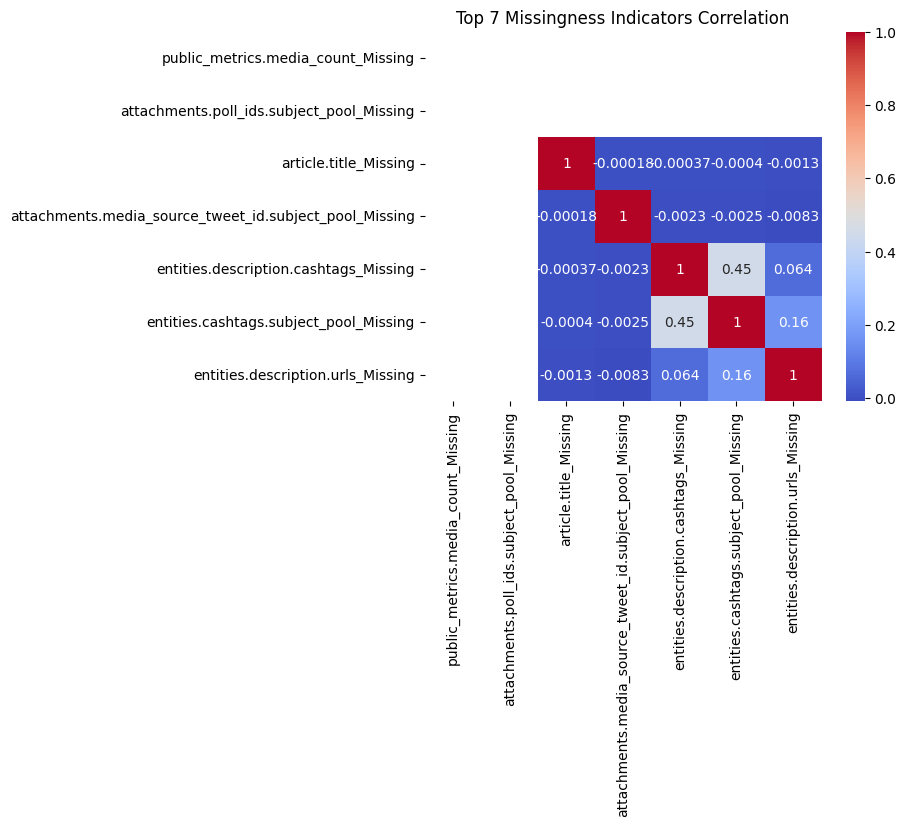

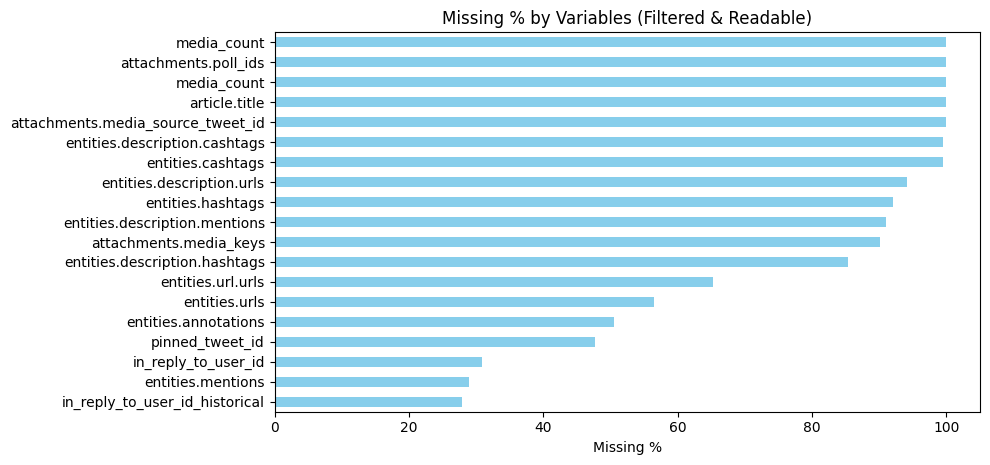

The dataset exhibits a mixed missingness structure. 42 variables are structurally missing, 2 appear Missing Completely At Random, 3 are likely Missing At Random, and 11 are likely Missing Not At Random. Overall, missingness is primarily systematic rather than random, indicating that absent values largely reflect platform or behavioral conditions rather than data corruption.


In [6]:
# %%
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

file_path = DATA_CSV
chunksize = 100_000

# STEP 1 — Overall Missingness for all variables
missing_counts = None
total_rows = 0

for chunk in pd.read_csv(file_path, chunksize=chunksize, dtype=str, low_memory=False):
    if missing_counts is None:
        missing_counts = chunk.isna().sum()
    else:
        missing_counts += chunk.isna().sum()
    total_rows += len(chunk)

missing_percent = (missing_counts / total_rows) * 100
missing_percent = missing_percent.sort_values(ascending=False)

print("Total rows:", total_rows)
print("\nMissing % by column:")
print(missing_percent)

# %%
# STEP 2 — Identify Structural Missingness
fully_missing = missing_percent[missing_percent == 100]
print("\n100% Missing Columns (Structural):")
print(fully_missing)

# %%
# STEP 3 — Define categories and variables
# categories dictionary is reused here
categories = {
    'User info': ['created_at.users', 'protected', 'verified_type', 'public_metrics.followers_count',
                  'public_metrics.following_count', 'public_metrics.tweet_count', 'public_metrics.listed_count',
                  'public_metrics.like_count.users', 'public_metrics.media_count', 'user_id_code'],
    'Tweet content / metadata': ['sampling_tweet', 'tweets_historical', 'lang.subject_pool', 'lang.tweets_historical',
                                 'entities.url.urls', 'entities.description.mentions', 'entities.description.hashtags',
                                 'entities.description.urls', 'entities.mentions.subject_pool', 'entities.urls.subject_pool',
                                 'entities.annotations.subject_pool', 'entities.hashtags.subject_pool',
                                 'entities.cashtags.subject_pool', 'entities.description.cashtags',
                                 'attachments.media_keys.subject_pool', 'attachments.media_source_tweet_id.subject_pool',
                                 'attachments.poll_ids.subject_pool', 'edit_history_tweet_ids.subject_pool',
                                 'possibly_sensitive'],
    'Engagement metrics': [],  # to fill after reading first chunk
    'Sampling / dataset info': ['pool_type', 'sampling_date', 'clean...pool', 'clean...pool.date',
                                'clean...state_simple', 'EXCLUDED', 'TEST', 'EXTRACTED_USER_TIMELINE'],
    'Conversation / reply tracking': ['conversation_id_code', 'conversation_id_historical_code',
                                      'in_reply_to_user_id_code', 'in_reply_to_user_id_historical_code',
                                      'most_recent_tweet_id_code', 'pinned_tweet_id_code', 'tweet_id_code',
                                      'tweet_id_historical_code'],
    'Articles / external references': ['article.title']
}

# First chunk to detect all engagement metrics dynamically
first_chunk = pd.read_csv(file_path, nrows=chunksize, dtype=str, low_memory=False)
categories['Engagement metrics'] = [col for col in first_chunk.columns if 'public_metrics' in col]

# %%
# STEP 4 — Create Missingness Indicators for all variables
all_vars = [col for sublist in categories.values() for col in sublist]
sample_cols = all_vars.copy()
sample_df_list = []

for chunk in pd.read_csv(file_path, chunksize=chunksize, usecols=lambda x: x in sample_cols, dtype=str, low_memory=False):
    # Create missingness indicators
    for col in chunk.columns:
        chunk[col + "_Missing"] = chunk[col].isna().astype(int)
    # Sample up to 5000 rows per chunk
    sample_df_list.append(chunk.sample(min(5000, len(chunk))))
    if len(sample_df_list) > 20:
        break

df_sample = pd.concat(sample_df_list, ignore_index=True)

# %%
# STEP 5 — Summary of Missingness by variable
missing_indicator_cols = [col for col in df_sample.columns if col.endswith("_Missing")]
print("\nMissingness distribution for sampled variables:")
for col in missing_indicator_cols:
    print(f"{col}:")
    print(df_sample[col].value_counts(normalize=True))

# %%
# STEP 6 — Convert numeric engagement metrics for MCAR tests
numeric_cols = ['public_metrics.like_count', 'public_metrics.retweet_count.tweets_historical']
for col in numeric_cols:
    if col in df_sample.columns:
        df_sample[col] = pd.to_numeric(df_sample[col], errors="coerce")

# Drop rows missing numeric predictors for MCAR tests
df_sample = df_sample.dropna(subset=[col for col in numeric_cols if col in df_sample.columns])

# %%
# STEP 7 — MCAR Tests for all partially missing variables
for var in missing_indicator_cols:
    y = df_sample[var]
    if y.nunique() > 1:  # Only test variables with variation
        X = df_sample[[col for col in numeric_cols if col in df_sample.columns]]
        X = sm.add_constant(X)
        model = sm.Logit(y, X)
        result = model.fit(disp=False)
        print(f"\nMCAR Test Summary for {var}:")
        print(result.summary())
    else:
        print(f"\n{var} has no missing values; MCAR test skipped.")

classification = {}

for var in missing_indicator_cols:
    y = df_sample[var]

    # skip constants
    if y.nunique() <= 1:
        classification[var] = "Structural (Always Missing or Never Missing)"
        continue

    X = df_sample[[col for col in numeric_cols if col in df_sample.columns]]
    X = sm.add_constant(X)

    try:
        result = sm.Logit(y, X).fit(disp=False)

        # check if ANY predictor significantly predicts missingness
        pvals = result.pvalues.drop("const", errors="ignore")

        if (pvals < 0.05).any():
            classification[var] = "MAR or MNAR"
        else:
            classification[var] = "MCAR"

    except:
        classification[var] = "Test Failed"

# convert to table
class_df = pd.DataFrame.from_dict(classification, orient="index", columns=["Missingness_Type"])
print(class_df.sort_values("Missingness_Type"))

content_keywords = ["entities", "hashtags", "urls", "mentions", "media", "poll"]

def refine(var, label):
    if label != "MAR or MNAR":
        return label
    if any(k in var for k in content_keywords):
        return "Likely MNAR (content-dependent)"
    return "Likely MAR (observed-data dependent)"

class_df["Refined"] = [refine(v, classification[v]) for v in class_df.index]

# %%
# STEP 8 — Correlation heatmap of missingness indicators
top_n = 7  # show top 15 missingness indicators
top_missing_cols = df_sample[missing_indicator_cols].mean().sort_values(ascending=False).head(top_n).index

sns.heatmap(df_sample[top_missing_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Top 7 Missingness Indicators Correlation")
plt.show()


# %%
# STEP 9 — Barplot of missingness %
# 1. Only keep variables with some missingness
missing_threshold = 0  # only show vars with >0% missing
vars_with_missing = [col for col in all_vars if df_sample[col].isna().mean() > missing_threshold]

# 2. Compute missing %
missing_percent_sample = df_sample[vars_with_missing].isna().mean() * 100

# 3. Shorten labels for readability
short_labels = {col: col.replace(".subject_pool", "")
                         .replace(".users", "")
                         .replace("public_metrics.", "")
                         .replace("clean...", "")
                         .replace("_code", "") 
                         for col in missing_percent_sample.index}

missing_percent_sample.rename(index=short_labels, inplace=True)

# 4. Plot
plt.figure(figsize=(10, len(vars_with_missing)*0.25))  # adjust height for many variables
missing_percent_sample.sort_values().plot(kind='barh', color='skyblue')
plt.xlabel("Missing %")
plt.title("Missing % by Variables (Filtered & Readable)")
plt.tight_layout()
plt.show()

counts = class_df["Refined"].value_counts()

report = (
    f"The dataset exhibits a mixed missingness structure. "
    f"{counts.get('Structural (Always Missing or Never Missing)',0)} variables are structurally missing, "
    f"{counts.get('MCAR',0)} appear Missing Completely At Random, "
    f"{counts.get('Likely MAR (observed-data dependent)',0)} are likely Missing At Random, "
    f"and {counts.get('Likely MNAR (content-dependent)',0)} are likely Missing Not At Random. "
    f"Overall, missingness is primarily systematic rather than random, indicating that absent values largely reflect platform or behavioral conditions rather than data corruption."
)

print(report)


# %%

## Missingness — swing-state coverage diagnostics

In [7]:
"""
Diagnostic script for Method_Exploration.ipynb: why the final sns.lineplot
may show only two state lines.

Hypotheses tested:
1) Only a subset of swing states appear in clean...state_simple after filters.
2) State labels in the CSV do not exactly match the swing_states list (string mismatch).
3) Some states have so few rows or so few distinct dates that they are effectively absent
   from state_daily (or collapse visually).

Run: set ELECTION_CSV to your CSV path, or edit DEFAULT_CSV below.

Uses only the Python standard library for CSV + stats (no pandas), so MSYS2 base Python works.
Optional: matplotlib + seaborn for PNG figures; otherwise CSV summaries are written.

MSYS2 plotting: pacman -S mingw-w64-x86_64-python-matplotlib mingw-w64-x86_64-python-seaborn
"""

from __future__ import annotations

import csv
import os
import sys
from collections import Counter
from datetime import date, datetime, timezone
from pathlib import Path
from typing import Iterator

try:
    import matplotlib.dates as mdates
    import matplotlib.pyplot as plt
    import seaborn as sns

    HAS_PLOTTING = True
except ImportError:
    mdates = None  # type: ignore[assignment]
    plt = None  # type: ignore[assignment]
    sns = None  # type: ignore[assignment]
    HAS_PLOTTING = False

# ---------------------------------------------------------------------------
# Config (same swing states and column names as Peilin/Method_Exploration.ipynb)
# ---------------------------------------------------------------------------
DEFAULT_CSV = os.environ.get("ELECTION_CSV", DATA_CSV)
CHUNK_SIZE = 100_000
SWING_STATES = [
    "Arizona",
    "Georgia",
    "Michigan",
    "Nevada",
    "North Carolina",
    "Pennsylvania",
    "Wisconsin",
]

COLS = frozenset(
    [
        "clean...state_simple",
        "created_at.users",
        "sampling_tweet",
    ]
)

CUTOFF_2024 = datetime(2024, 1, 1, tzinfo=timezone.utc)


def parse_utc_datetime(s: str | None) -> datetime | None:
    """Parse created_at.users to timezone-aware UTC (best-effort, stdlib only)."""
    if s is None:
        return None
    s = str(s).strip()
    if not s or s.lower() in ("nan", "nat", "none"):
        return None
    s_iso = s.replace("Z", "+00:00")
    try:
        dt = datetime.fromisoformat(s_iso)
    except ValueError:
        return None
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    else:
        dt = dt.astimezone(timezone.utc)
    return dt


def normalize_utc_day(dt: datetime) -> datetime:
    dt = dt.astimezone(timezone.utc)
    return dt.replace(hour=0, minute=0, second=0, microsecond=0)


def iter_csv_chunks(
    csv_path: str,
    max_chunks: int | None = None,
) -> Iterator[list[dict[str, str]]]:
    """Yield list-of-dicts chunks with only COLS keys (same idea as pandas usecols)."""
    n_chunks = 0
    with open(csv_path, newline="", encoding="utf-8", errors="replace") as f:
        reader = csv.reader(f)
        try:
            header_row = next(reader)
        except StopIteration:
            return
        header = [h.strip().lstrip("\ufeff") for h in header_row]
        idx = {name: header.index(name) for name in COLS if name in header}
        if len(idx) != len(COLS):
            missing = COLS - set(idx.keys())
            raise ValueError(f"CSV missing required columns: {missing}")

        buf: list[dict[str, str]] = []
        for row in reader:
            rec = {c: (row[idx[c]] if idx[c] < len(row) else "") for c in COLS}
            buf.append(rec)
            if len(buf) >= CHUNK_SIZE:
                yield buf
                buf = []
                n_chunks += 1
                if max_chunks is not None and n_chunks >= max_chunks:
                    return
        if buf:
            yield buf


def process_chunk_swing_rows(
    chunk: list[dict[str, str]],
) -> list[tuple[str, datetime]]:
    """Apply notebook filters; return list of (state, utc_datetime) for swing states."""
    out: list[tuple[str, datetime]] = []
    for rec in chunk:
        st = (rec.get("clean...state_simple") or "").strip()
        tw = (rec.get("sampling_tweet") or "").strip()
        created = rec.get("created_at.users")
        if not st or not tw or not (created and str(created).strip()):
            continue
        if st not in SWING_STATES:
            continue
        dt = parse_utc_datetime(created)
        if dt is None:
            continue
        out.append((st, dt))
    return out


def count_rows_per_state(
    csv_path: str, max_chunks: int | None = None
) -> dict[str, int]:
    counts: Counter[str] = Counter()
    for chunk in iter_csv_chunks(csv_path, max_chunks=max_chunks):
        for state, _dt in process_chunk_swing_rows(chunk):
            counts[state] += 1
    return {s: int(counts.get(s, 0)) for s in SWING_STATES}


def collect_state_date_stream(
    csv_path: str, max_chunks: int | None = None
) -> tuple[dict[str, tuple[datetime, datetime]], dict[str, set[date]]]:
    """
    Full pass: per-state min/max datetime; per-state set of UTC calendar dates in 2024+.
    """
    bounds: dict[str, list[datetime]] = {s: [] for s in SWING_STATES}
    days_2024: dict[str, set[date]] = {s: set() for s in SWING_STATES}

    for chunk in iter_csv_chunks(csv_path, max_chunks=max_chunks):
        for state, dt in process_chunk_swing_rows(chunk):
            bounds[state].append(dt)
            nd = normalize_utc_day(dt)
            if nd >= CUTOFF_2024:
                days_2024[state].add(nd.date())

    minmax: dict[str, tuple[datetime | None, datetime | None]] = {}
    for s in SWING_STATES:
        xs = bounds[s]
        if not xs:
            minmax[s] = (None, None)
        else:
            minmax[s] = (min(xs), max(xs))

    return minmax, days_2024


def top_raw_state_labels(csv_path: str, first_chunks: int = 3) -> dict[str, int]:
    """Value counts of clean...state_simple before swing filter (first N chunks only)."""
    counts: Counter[str] = Counter()
    for chunk in iter_csv_chunks(csv_path, max_chunks=first_chunks):
        for rec in chunk:
            st = (rec.get("clean...state_simple") or "").strip()
            tw = (rec.get("sampling_tweet") or "").strip()
            created = rec.get("created_at.users")
            if not st or not tw or not (created and str(created).strip()):
                continue
            counts[st] += 1
    return dict(counts.most_common(40))


def states_with_positive_rows(row_counts: dict[str, int]) -> list[str]:
    return [s for s in SWING_STATES if row_counts.get(s, 0) > 0]


def _write_csv_dict(path: Path, data: dict[str, int], value_header: str) -> None:
    with open(path, "w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["key", value_header])
        for k in sorted(data.keys()):
            w.writerow([k, data[k]])


def plot_diagnostics(
    row_counts: dict[str, int],
    distinct_days: dict[str, int],
    out_dir: Path,
    raw_top: dict[str, int] | None = None,
    date_bounds: dict[str, tuple[datetime | None, datetime | None]] | None = None,
) -> None:
    """Save figures (or CSV only if matplotlib is unavailable)."""
    out_dir.mkdir(parents=True, exist_ok=True)

    if not HAS_PLOTTING or plt is None or sns is None or mdates is None:
        _write_csv_dict(out_dir / "rows_per_swing_state.csv", row_counts, "row_count")
        _write_csv_dict(out_dir / "distinct_days_2024plus.csv", distinct_days, "distinct_days")
        if date_bounds:
            with open(out_dir / "date_bounds_per_state.csv", "w", newline="", encoding="utf-8") as f:
                w = csv.writer(f)
                w.writerow(["state", "min_date", "max_date"])
                for s in SWING_STATES:
                    lo, hi = date_bounds.get(s, (None, None))
                    w.writerow([s, lo.isoformat() if lo else "", hi.isoformat() if hi else ""])
        if raw_top:
            with open(out_dir / "top_state_labels_sample.csv", "w", newline="", encoding="utf-8") as f:
                w = csv.writer(f)
                w.writerow(["state", "rows_in_sample"])
                for k, v in sorted(raw_top.items(), key=lambda x: -x[1]):
                    w.writerow([k, v])
        print(
            "\nmatplotlib/seaborn not installed — skipped PNG figures; wrote CSV summaries to",
            out_dir,
        )
        print(
            "MSYS2: pacman -S mingw-w64-x86_64-python-matplotlib mingw-w64-x86_64-python-seaborn"
        )
        return

    sns.set_theme(style="whitegrid")
    states = SWING_STATES
    rc = [row_counts[s] for s in states]
    colors = ["#2ecc71" if row_counts[s] > 0 else "#e74c3c" for s in states]

    fig1, ax1 = plt.subplots(figsize=(10, 5))
    ax1.bar(states, rc, color=colors)
    ax1.set_title("Tweet rows per swing state (after notebook filters, chunked count)")
    ax1.set_xlabel("clean...state_simple")
    ax1.set_ylabel("Row count")
    ax1.tick_params(axis="x", rotation=45)
    fig1.tight_layout()
    fig1.savefig(out_dir / "rows_per_swing_state.png", dpi=150)
    plt.close(fig1)

    dd = [distinct_days[s] for s in states]
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.bar(states, dd, color="steelblue")
    ax2.set_title("Distinct calendar days with data per state (date >= 2024-01-01)")
    ax2.set_xlabel("State")
    ax2.set_ylabel("Distinct days")
    ax2.tick_params(axis="x", rotation=45)
    ax2.axhline(1, color="orange", linestyle="--", linewidth=1, label="1 day (single point line)")
    ax2.legend(loc="upper right")
    fig2.tight_layout()
    fig2.savefig(out_dir / "distinct_days_per_state.png", dpi=150)
    plt.close(fig2)

    if raw_top:
        labels = list(raw_top.keys())
        vals = [raw_top[k] for k in labels]
        fig3, ax3 = plt.subplots(figsize=(10, 6))
        ax3.barh(labels[::-1], vals[::-1], color="gray")
        ax3.set_title("Top state strings in CSV (sample chunks, before swing filter)")
        ax3.set_xlabel("Row count (partial file sample)")
        fig3.tight_layout()
        fig3.savefig(out_dir / "top_state_labels_sample.png", dpi=150)
        plt.close(fig3)

    if date_bounds:
        db = {
            s: date_bounds[s]
            for s in SWING_STATES
            if date_bounds[s][0] is not None and date_bounds[s][1] is not None
        }
        if db:
            fig4, ax4 = plt.subplots(figsize=(11, 6))
            keys = list(db.keys())
            for i, state in enumerate(keys):
                lo, hi = db[state]
                assert lo is not None and hi is not None
                ax4.plot([lo, hi], [i, i], color="teal", linewidth=4, solid_capstyle="round")
            ax4.set_yticks(range(len(keys)))
            ax4.set_yticklabels(keys)
            ax4.axvline(
                CUTOFF_2024,
                color="red",
                linestyle="--",
                linewidth=1.5,
                label="Notebook: date >= 2024-01-01",
            )
            ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
            ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            ax4.set_xlabel("created_at.users")
            ax4.set_title(
                "Date range of tweets per swing state (if max < cutoff, state drops from state_daily)"
            )
            ax4.legend(loc="lower right")
            fig4.autofmt_xdate()
            fig4.tight_layout()
            fig4.savefig(out_dir / "date_span_per_state.png", dpi=150)
            plt.close(fig4)


def main() -> int:
    csv_path = sys.argv[1] if len(sys.argv) > 1 else DEFAULT_CSV
    max_chunks_env = os.environ.get("MAX_CHUNKS")
    max_chunks = int(max_chunks_env) if max_chunks_env else None

    out_dir = DATA_DIR / "test_missing_state_output"

    if not Path(csv_path).is_file():
        print(f"ERROR: CSV not found: {csv_path}")
        print("Set ELECTION_CSV or pass path as first argument.")
        return 1

    print(f"Using CSV: {csv_path}")
    if max_chunks:
        print(f"MAX_CHUNKS={max_chunks} (subset run for speed)")

    print("\n--- Top clean...state_simple values (first 3 chunks, before swing filter) ---")
    raw_top = top_raw_state_labels(csv_path, first_chunks=3)
    for k, v in sorted(raw_top.items(), key=lambda x: -x[1])[:40]:
        print(f"{k:25s} {v}")

    print("\n--- Row counts per swing state (after filters, isin swing_states) ---")
    row_counts = count_rows_per_state(csv_path, max_chunks=max_chunks)
    for s in SWING_STATES:
        print(f"{s:18s} {row_counts[s]}")

    present = states_with_positive_rows(row_counts)
    print(f"\nStates with >0 rows: {len(present)} -> {present}")

    print("\n--- Min/max dates and distinct 2024+ days (full pass over filtered rows) ---")
    date_bounds, days_2024 = collect_state_date_stream(csv_path, max_chunks=max_chunks)
    distinct_days = {s: len(days_2024[s]) for s in SWING_STATES}

    print("\n--- Min / max tweet date per state (all rows; compare to 2024-01-01 cutoff) ---")
    for s in SWING_STATES:
        lo, hi = date_bounds[s]
        print(f"{s:18s} min={lo} max={hi}")

    print("\n--- Distinct days with >=1 row per state (date >= 2024-01-01) ---")
    for s in SWING_STATES:
        print(f"{s:18s} {distinct_days[s]}")

    n_rows_any_state = sum(1 for s in SWING_STATES if row_counts[s] > 0)
    n_states_after_2024 = sum(1 for s in SWING_STATES if distinct_days[s] > 0)
    print("\n--- Interpretation vs Method_Exploration.ipynb lineplot ---")
    print(
        "The notebook applies state_daily = state_daily[state_daily['date'] >= '2024-01-01']. "
        "States with no rows on or after that date disappear from state_daily, so sns.lineplot "
        "has fewer hue levels than the seven swing states."
    )
    print(
        f"Chunked counts: {n_rows_any_state} swing state(s) have >0 tweet rows after basic filters; "
        f"after the 2024-01-01 filter, {n_states_after_2024} state(s) have >=1 distinct calendar day."
    )
    if n_states_after_2024 <= 2:
        print(
            "Finding: Most swing-state volume may fall entirely before 2024-01-01 (see date_span_per_state.png). "
            "That yields at most a couple of lines in the final plot even when raw row counts look large."
        )
    elif n_states_after_2024 < 7:
        print(
            "Finding: Some states have tweets only before 2024-01-01 (distinct_days=0 for those); "
            "they are excluded from state_daily and do not appear in the lineplot."
        )
    if n_rows_any_state < 7:
        print(
            "Also check string mismatch: see top_state_labels_sample.png if some swing states never appear."
        )

    plot_diagnostics(
        row_counts,
        distinct_days,
        out_dir,
        raw_top=raw_top,
        date_bounds=date_bounds,
    )
    print(f"\nFigures saved under: {out_dir}")
    return 0


main()

ERROR: CSV not found: --f=c:\Users\19241\AppData\Roaming\jupyter\runtime\kernel-v33ba83bad727750de2cb89a8cf0f31edd75829b6e.json
Set ELECTION_CSV or pass path as first argument.


1

## Data cleaning

In [8]:
import numpy as np
import pandas as pd

FILE_IN = DATA_CSV
FILE_OUT = DATA_DIR / 'subjects_cleaned_basic.csv'

dtype_map = {
    "entities.url.urls": "string",
    "attachments.media_keys.subject_pool": "string",
    "attachments.media_source_tweet_id.tweets_historical": "string",
}

NROWS = 100000  # None

def load_raw():
    return pd.read_csv(
        FILE_IN,
        nrows=NROWS,
        dtype=dtype_map,
        low_memory=False,
    )


def basic_clean(df: pd.DataFrame) -> pd.DataFrame:
    """Most basic data cleaning: names, typo, dates, types, filters."""
    df = df.copy()

    # 1. Rename columns (clean...* -> clean_*)
    renames = {
        "clean...pool": "clean_pool",
        "clean...pool.date": "clean_pool_date",
        "clean...state_simple": "clean_state_simple",
    }
    df = df.rename(columns={k: v for k, v in renames.items() if k in df.columns})

    # 2. Fix typo
    if "clean_pool" in df.columns:
        df["clean_pool"] = df["clean_pool"].replace("frees speech", "free speech")

    # 3. Parse datetime columns
    for col in ["created_at", "created_at.tweets", "created_at.users", "sampling_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], utc=True, errors="coerce")

    # 4. Ensure ID columns are string (avoid scientific notation)
    id_cols = [c for c in df.columns if c.endswith("_code")]
    for col in id_cols:
        df[col] = df[col].astype("string")

    # 5. Basic filters: keep only non-excluded, non-test
    if "EXCLUDED" in df.columns:
        df = df[df["EXCLUDED"].astype(str).str.lower() == "no"]
    if "TEST" in df.columns:
        df = df[df["TEST"].astype(str).str.lower() == "no"]

    # 6. Drop rows missing key analysis fields
    for col in ["clean_pool", "sampling_date"]:
        if col in df.columns:
            df = df[df[col].notna()]

    return df


if __name__ == "__main__":
    df = load_raw()
    n_before = len(df)
    df = basic_clean(df)
    n_after = len(df)

    df.to_csv(FILE_OUT, index=False, date_format="%Y-%m-%dT%H:%M:%SZ")
    print(f"Rows: {n_before} -> {n_after}")
    print(f"Saved: {FILE_OUT}")
    print(df.head(5))

Rows: 100000 -> 100000
Saved: D:\Project\data\subjects_cleaned_basic.csv
           created_at.users  protected verified_type  \
0 2019-01-05 12:46:57+00:00      False          none   
1 2019-01-05 12:46:57+00:00      False          none   
2 2019-01-05 12:46:57+00:00      False          none   
3 2019-01-05 12:46:57+00:00      False          none   
4 2019-01-05 12:46:57+00:00      False          none   

   public_metrics.followers_count  public_metrics.following_count  \
0                            4426                            1240   
1                            4426                            1240   
2                            4426                            1240   
3                            4426                            1240   
4                            4426                            1240   

   public_metrics.tweet_count  public_metrics.listed_count  \
0                       96732                           33   
1                       96732                      

## Feature engineering — swing-state tweets (chunked)

In [9]:
import ast

import pandas as pd

file_path = DATA_CSV
chunk_size = 100_000

cols_needed = [
    "clean...state_simple",
    "created_at.users",
    "tweets_historical",
    "sampling_tweet",
    "entities.hashtags.subject_pool",
    "public_metrics.like_count",
    "public_metrics.retweet_count.tweets_historical",
]

df_list = []
swing_states = [
    "Arizona", "Georgia", "Michigan", "Nevada",
    "North Carolina", "Pennsylvania", "Wisconsin",
]

for chunk in pd.read_csv(
    file_path,
    chunksize=chunk_size,
    usecols=lambda x: x in cols_needed,
    dtype=str,
    low_memory=False,
):
    chunk = chunk.dropna(
        subset=["created_at.users", "clean...state_simple", "sampling_tweet"]
    )
    chunk["date"] = pd.to_datetime(chunk["created_at.users"], errors="coerce", utc=True)
    chunk["like_count"] = pd.to_numeric(
        chunk["public_metrics.like_count"], errors="coerce"
    )
    chunk["retweet_count"] = pd.to_numeric(
        chunk["public_metrics.retweet_count.tweets_historical"], errors="coerce"
    )
    chunk = chunk[chunk["clean...state_simple"].isin(swing_states)]

    historical_rows = []
    for _, row in chunk.iterrows():
        hist_raw = row.get("tweets_historical")
        if pd.isna(hist_raw) or isinstance(hist_raw, float) or str(hist_raw).strip() == "":
            continue
        try:
            hist_tweets = ast.literal_eval(hist_raw)
            if isinstance(hist_tweets, dict):
                hist_tweets = [hist_tweets]
            if not isinstance(hist_tweets, list):
                continue
        except (ValueError, SyntaxError):
            continue

        for ht in hist_tweets:
            try:
                if isinstance(ht, dict):
                    text = ht.get("text", "")
                    date = pd.to_datetime(ht.get("created_at"), errors="coerce", utc=True)
                    like_count = pd.to_numeric(ht.get("like_count"), errors="coerce")
                    retweet_count = pd.to_numeric(ht.get("retweet_count"), errors="coerce")
                else:
                    text = str(ht)
                    date = row["date"]
                    like_count = row["like_count"]
                    retweet_count = row["retweet_count"]
                historical_rows.append({
                    "clean...state_simple": row["clean...state_simple"],
                    "sampling_tweet": text,
                    "date": date,
                    "like_count": like_count,
                    "retweet_count": retweet_count,
                    "entities.hashtags.subject_pool": row.get(
                        "entities.hashtags.subject_pool", None
                    ),
                })
            except Exception:
                continue

    chunk_hist = pd.DataFrame(historical_rows) if historical_rows else pd.DataFrame()
    combined = pd.concat([chunk, chunk_hist], ignore_index=True)
    df_list.append(combined)

df = pd.concat(df_list, ignore_index=True)
start_date = pd.Timestamp("2024-01-01", tz="UTC")
end_date = pd.Timestamp("2024-11-05", tz="UTC")
df = df[(df["date"] >= start_date) & (df["date"] <= end_date)]
df = df.drop_duplicates(
    subset=["sampling_tweet", "date", "clean...state_simple"]
).reset_index(drop=True)

print(f"Total tweets in swing states from 2024-01-01 to Election Day: {len(df)}")

<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:1: SyntaxWarning: invalid decimal literal
<unknown>:3: SyntaxWarning: invalid decimal literal
<unknown>:3:

Total tweets in swing states from 2024-01-01 to Election Day: 12


## Topic modeling (LDA)

In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# =========================
# 1. LOAD DATA (CHUNKED)
# =========================
file_path = DATA_CSV
df_iter = pd.read_csv(file_path, chunksize=10000)

start_date = "2024-01-01"
end_date = "2024-11-05"

all_comments = []

# =========================
# 2. EXTRACT RELEVANT COMMENTS
# =========================
for i, chunk in enumerate(df_iter):
    print(f"Processing chunk {i}...")

    data = chunk.copy()

    # Convert datetime
    data['created_at'] = pd.to_datetime(data['created_at'], errors='coerce')

    # Filter date range
    df_2024 = data[
        (data['created_at'] >= start_date) &
        (data['created_at'] <= end_date)
    ]

    # Keep replies only (comments)
    df_comments = df_2024[
        df_2024['in_reply_to_user_id_code'].notna()
    ]

    # Keep rows with state + text
    df_comments = df_comments[
        df_comments['clean...state_simple'].notna()
    ]

    df_comments = df_comments[
        ['tweets_historical', 'clean...state_simple']
    ].dropna()

    all_comments.append(df_comments)

# Combine all chunks
comments_df = pd.concat(all_comments, ignore_index=True)

print("\nTotal comments collected:", len(comments_df))


# =========================
# 3. FILTER ELECTION-RELATED COMMENTS
# =========================
keywords = [
    "election", "vote", "voting", "ballot", "president",
    "trump", "biden", "democrat", "republican",
    "campaign", "poll", "electoral", "debate"
]

pattern = "|".join(keywords)

filtered_df = comments_df[
    comments_df['tweets_historical'].str.contains(pattern, case=False, na=False)
]

print("Election-related comments:", len(filtered_df))


# =========================
# 4. TEXT VECTORIZATION (LDA INPUT)
# =========================
print("\nVectorizing text...")

vectorizer = CountVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=10
)

X = vectorizer.fit_transform(filtered_df['tweets_historical'])

print("Document-term matrix shape:", X.shape)


# =========================
# 5. RUN LDA
# =========================
print("\nRunning LDA...")

n_topics = 10  # you can tune this
lda_model = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42
)

lda_model.fit(X)


# =========================
# 6. ASSIGN TOPICS TO COMMENTS
# =========================
topic_distribution = lda_model.transform(X)

# Assign dominant topic
filtered_df['topic'] = topic_distribution.argmax(axis=1)


# =========================
# 7. EXTRACT TOP WORDS PER TOPIC
# =========================
words = vectorizer.get_feature_names_out()

topic_summary = []

for topic_idx, topic in enumerate(lda_model.components_):
    top_words = [words[i] for i in topic.argsort()[-10:]]
    topic_summary.append({
        "topic": topic_idx,
        "top_words": ", ".join(top_words)
    })

topic_summary_df = pd.DataFrame(topic_summary)

print("\nTopic Overview:")
print(topic_summary_df.head(10))


# =========================
# 8. SAVE RESULTS
# =========================
filtered_df.to_csv(DATA_DIR / 'comments_with_topics.csv', index=False)
topic_summary_df.to_csv(DATA_DIR / 'topic_summary.csv', index=False)

print("\nSaved:")
print("- comments_with_topics.csv")
print("- topic_summary.csv")


# =========================
# 9. STATE-TOPIC ANALYSIS
# =========================
state_topic_counts = (
    filtered_df
    .groupby(['clean...state_simple', 'topic'])
    .size()
    .reset_index(name='count')
)

state_topic_counts.to_csv(DATA_DIR / 'state_topic_counts.csv', index=False)

print("\nSaved:")
print("- state_topic_counts.csv")


# =========================
# 10. OPTIONAL: PRINT SAMPLE TOPICS
# =========================
print("\nSample Topics:\n")

for _, row in topic_summary_df.head(5).iterrows():
    print(f"Topic {row['topic']}:")
    print(row['top_words'])
    print("-" * 40)

C:\Users\19241\AppData\Local\Temp\ipykernel_15992\2762570244.py:19: DtypeWarning: Columns (9,29,56) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(df_iter):


Processing chunk 0...


C:\Users\19241\AppData\Local\Temp\ipykernel_15992\2762570244.py:19: DtypeWarning: Columns (15,56,58,59) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(df_iter):


Processing chunk 1...


C:\Users\19241\AppData\Local\Temp\ipykernel_15992\2762570244.py:19: DtypeWarning: Columns (11,18,53,54,58) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(df_iter):


...

Processing chunk 212...


C:\Users\19241\AppData\Local\Temp\ipykernel_15992\2762570244.py:19: DtypeWarning: Columns (10,29) have mixed types. Specify dtype option on import or set low_memory=False.
  for i, chunk in enumerate(df_iter):


Processing chunk 213...
Processing chunk 214...

Total comments collected: 1140639
Election-related comments: 246862

Vectorizing text...
Document-term matrix shape: (246862, 21548)

Running LDA...


C:\Users\19241\AppData\Local\Temp\ipykernel_15992\2762570244.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['topic'] = topic_distribution.argmax(axis=1)



Topic Overview:
   topic                                          top_words
0      0  says, president, campaign, iran, cnn, biden, k...
1      1  gives, illegal, harris, day, service, left, im...
2      2  aliens, harris, help, americans, fema, biden, ...
3      3  think, need, didn, harris, biden, administrati...
4      4  policies, harris, amp, biden, open, 100, state...
5      5  dnc, low, https, released, conspiracy, enrich,...
6      6  debt, high, inflation, poorer, failed, kamalah...
7      7  republicans, don, people, just, president, lik...
8      8  defeat, elect, donald, let, walz, 2025, projec...
9      9  like, votes, don, voting, biden, election, peo...

Saved:
- comments_with_topics.csv
- topic_summary.csv

Saved:
- state_topic_counts.csv

Sample Topics:

Topic 0:
says, president, campaign, iran, cnn, biden, kamala, harris, https, lies
----------------------------------------
Topic 1:
gives, illegal, harris, day, service, left, immigrants, citizens, https, biden
-------

## Topic modeling — swing states only

In [11]:
import pandas as pd

# Load dataset
df = pd.read_csv(DATA_DIR / 'comments_with_topics.csv')

# Make a copy
swing_df = df.copy()

# Define swing states
swing_states = [
    "Arizona",
    "Georgia",
    "Michigan",
    "Nevada",
    "North Carolina",
    "Pennsylvania",
    "Wisconsin"
]

# Keep ONLY rows where state_simple is a swing state
swing_df = swing_df[
    swing_df["clean...state_simple"].isin(swing_states)
]

# Count comments for each state and topic
counts = (
    swing_df
    .groupby(["clean...state_simple", "topic"])
    .size()
    .reset_index(name="count")
)

# Sort output
counts = counts.sort_values(
    by=["clean...state_simple", "topic"]
)

# Print results
print(counts)

# Save counts file
counts.to_csv(DATA_DIR / 'swing_state_topic_counts.csv', index=False)

# Optional: show states included
print("\nSwing states found:")
print(swing_df["clean...state_simple"].unique())

import pandas as pd

df = pd.read_csv(DATA_DIR / 'state_topic_counts.csv')

# Define swing states
swing_states = [
    "Arizona",
    "Georgia",
    "Michigan",
    "Nevada",
    "North Carolina",
    "Pennsylvania",
    "Wisconsin"
]

# Filter
df_swing = df[df['clean...state_simple'].isin(swing_states)]

# Save to new file
df_swing.to_csv(DATA_DIR / 'swing_state_topic_counts_only.csv', index=False)

# Print preview
print(df_swing)
print("\nSaved to swing_state_topic_counts_only.csv")

   clean...state_simple  topic  count
0               Arizona      0     71
1               Arizona      1    100
2               Arizona      2    190
3               Arizona      3    500
4               Arizona      4    572
..                  ...    ...    ...
65            Wisconsin      5     12
66            Wisconsin      6     33
67            Wisconsin      7   2997
68            Wisconsin      8    133
69            Wisconsin      9   1079

[70 rows x 3 columns]

Swing states found:
['Pennsylvania' 'North Carolina' 'Michigan' 'Wisconsin' 'Nevada' 'Georgia'
 'Arizona']
    clean...state_simple  topic  count
3                Arizona      0     71
4                Arizona      1    100
5                Arizona      2    190
6                Arizona      3    500
7                Arizona      4    572
..                   ...    ...    ...
408            Wisconsin      5     12
409            Wisconsin      6     33
410            Wisconsin      7   2997
411            Wisconsi

## Difference-in-differences & daily panel


Event: campaign_start
                            OLS Regression Results                            
Dep. Variable:             log_volume   R-squared:                       0.687
Model:                            OLS   Adj. R-squared:                  0.677
Method:                 Least Squares   F-statistic:                     75.58
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:27:04   Log-Likelihood:                -27345.
No. Observations:               22680   AIC:                         5.613e+04
Df Residuals:                   21962   BIC:                         6.189e+04
Df Model:                         717                                         
Covariance Type:                  HC3                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

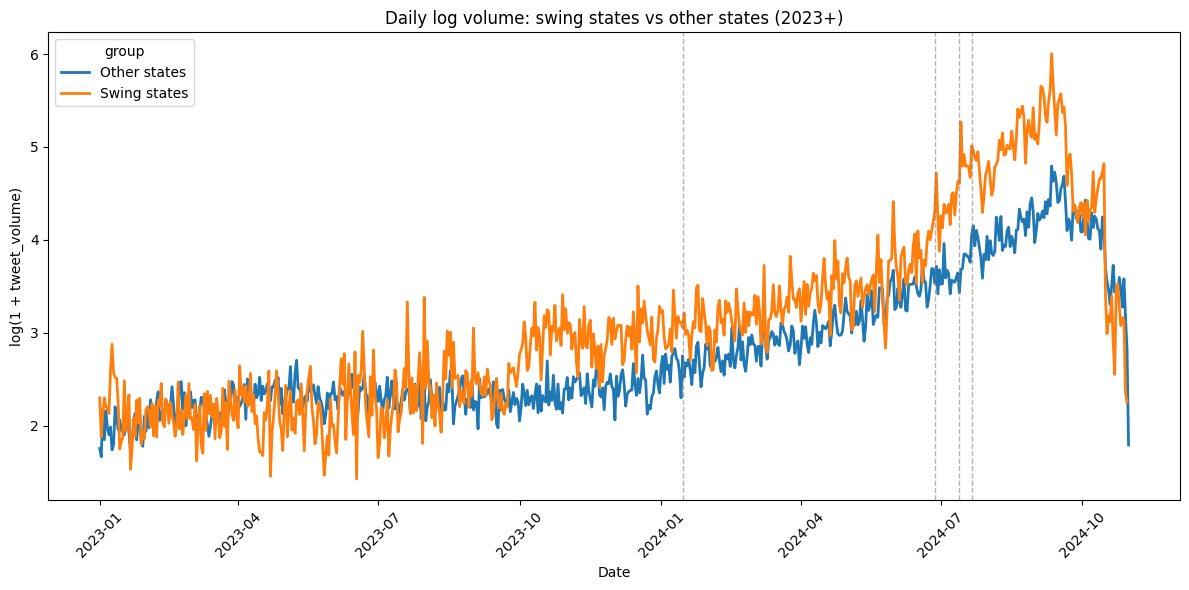


Data range: 2023-01-01 to 2024-10-31
Panel: 22,680 state-days, 48 states


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# ================================
# 1. LOAD DATA
# ================================
file_path = DATA_CSV

df = pd.read_csv(
    file_path,
    usecols=[
        "created_at",
        "tweets_historical",
        "clean...state_simple",
        "in_reply_to_user_id_code",
    ],
    dtype={
        "clean...state_simple": "string",
        "in_reply_to_user_id_code": "string",
    },
    low_memory=False,
)

# ================================
# 2. CLEAN
# ================================
df = df.dropna(subset=["created_at", "clean...state_simple"])

# Parse UTC timestamps and collapse to calendar days (not raw timestamps)
df["date"] = pd.to_datetime(df["created_at"], errors="coerce", utc=True).dt.normalize()
df = df.dropna(subset=["date"])

df.rename(columns={"clean...state_simple": "state"}, inplace=True)
df["state"] = df["state"].str.strip()

# Restrict to the election cycle window so pre-2024 noise does not dominate
analysis_start = pd.Timestamp("2023-01-01", tz="UTC")
df = df[df["date"] >= analysis_start].copy()

# ------------------------------------------------------------------
# AMBIGUOUS-LABEL HANDLING (mitigation strategy 1)
# "USA", "Unknown", etc. are aggregate/non-state labels. They are not
# real state-level signal and would pollute the non-swing control group,
# so we flag them, keep them only for the concentration audit, and drop
# them from the causal (DiD) panel.
# ------------------------------------------------------------------
AMBIGUOUS_LABELS = {
    "USA", "United States", "Unknown", "unknown", "Other",
    "N/A", "NA", "None", "", "nan",
}
df["is_ambiguous_state"] = df["state"].isin(AMBIGUOUS_LABELS)
n_ambiguous = int(df["is_ambiguous_state"].sum())

# Full frame (incl. ambiguous labels) is retained for the concentration audit;
# df is the cleaned state-level panel used for causal estimation.
df_full = df.copy()
df = df[~df["is_ambiguous_state"]].copy()

# ================================
# 3. TREATMENT: SWING STATES VS ALL OTHERS
# ================================
swing_states = [
    "Arizona", "Georgia", "Michigan",
    "Nevada", "North Carolina",
    "Pennsylvania", "Wisconsin",
]

df["treated"] = df["state"].isin(swing_states).astype(int)

# ================================
# 4. DAILY AGGREGATION (STATE x CALENDAR DAY)
# ================================
# tweets_historical holds tweet text; count = sampled subjects per state-day
daily = df.groupby(["state", "date"], as_index=False).agg(
    tweet_volume=("tweets_historical", "count"),
    reply_volume=("in_reply_to_user_id_code", lambda x: x.notna().sum()),
    treated=("treated", "max"),
)

daily["log_volume"] = np.log1p(daily["tweet_volume"])

# Within-state normalization (mitigation strategy 1): standardize each
# state against its own baseline so high-volume states do not dominate the
# pooled signal. This is the bias-corrected outcome used in robustness checks.
def _zscore(x):
    sd = x.std(ddof=0)
    return (x - x.mean()) / sd if sd > 0 else x * 0.0

daily["log_volume_state_z"] = (
    daily.groupby("state")["log_volume"].transform(_zscore)
)

# Use plain str labels for formula API compatibility (not pandas StringDtype)
daily["state_id"] = daily["state"].astype(str)
daily["date_id"] = daily["date"].dt.strftime("%Y-%m-%d")

# ================================
# 5. EVENT DEFINITIONS
# ================================
events = {
    "campaign_start": "2024-01-15",
    "debate": "2024-06-27",
    "trump_incident": "2024-07-13",
    "biden_dropout": "2024-07-21",
    # election_day omitted: data ends 2024-10-31, no post-window coverage
}

data_end = daily["date"].max()

# ================================
# 6. EVENT WINDOWS (LEAD / POST RELATIVE TO EACH EVENT)
# ================================
for event_name, event_date in events.items():
    event_dt = pd.to_datetime(event_date, utc=True)
    daily[f"{event_name}_time"] = (daily["date"] - event_dt).dt.days

    daily[f"{event_name}_lead"] = (
        (daily[f"{event_name}_time"] >= -10) & (daily[f"{event_name}_time"] <= -1)
    ).astype(int)
    daily[f"{event_name}_post"] = (
        (daily[f"{event_name}_time"] >= 0) & (daily[f"{event_name}_time"] <= 10)
    ).astype(int)
    daily[f"{event_name}_did"] = daily["treated"] * daily[f"{event_name}_post"]

# ================================
# 7. DIFFERENCE-IN-DIFFERENCES (ONE EVENT PER MODEL)
# ================================
# State FE absorbs time-invariant treated; date FE absorbs national shocks.
# Do not include a separate 'treated' level term (collinear with C(state_id)).
# Estimate events separately to avoid overlapping post-window collinearity.

def run_event_did(data, event_name):
    """OLS DiD for a single event with state and calendar-day fixed effects."""
    did_col = f"{event_name}_did"
    post_col = f"{event_name}_post"

    if data[post_col].sum() == 0:
        return None

    formula = f"log_volume ~ {did_col} + C(state_id) + C(date_id)"
    return smf.ols(formula, data=data).fit(cov_type="HC3")


results = []
for event_name in events:
    model = run_event_did(daily, event_name)
    if model is None:
        results.append({
            "event": event_name,
            "coef": np.nan,
            "std_err": np.nan,
            "p_value": np.nan,
            "n_obs": len(daily),
            "note": "no post-window observations",
        })
        continue

    did_col = f"{event_name}_did"
    results.append({
        "event": event_name,
        "coef": model.params[did_col],
        "std_err": model.bse[did_col],
        "p_value": model.pvalues[did_col],
        "n_obs": int(model.nobs),
        "r_squared": model.rsquared,
        "note": "",
    })
    print(f"\n{'=' * 60}\nEvent: {event_name}\n{'=' * 60}")
    print(model.summary())

effects = pd.DataFrame(results)
print("\n=== DiD treatment effects (log volume, one model per event) ===")
print(effects.to_string(index=False))

# ================================
# 8. PARALLEL TRENDS CHECK (LEAD INTERACTION, SINGLE EVENT EXAMPLE)
# ================================
# If pre-trends are flat, treated x lead should be insignificant.
example_event = "debate"
lead_col = f"{example_event}_lead"
daily[f"{example_event}_lead_did"] = daily["treated"] * daily[lead_col]

pretrend_formula = (
    f"log_volume ~ {example_event}_lead_did + {example_event}_did "
    f"+ C(state_id) + C(date_id)"
)
pretrend_model = smf.ols(pretrend_formula, data=daily).fit(cov_type="HC3")
print(f"\n=== Parallel trends check ({example_event}: lead x treated) ===")
print(
    f"lead_did coef = {pretrend_model.params[f'{example_event}_lead_did']:.4f}, "
    f"p = {pretrend_model.pvalues[f'{example_event}_lead_did']:.4f}"
)

# ================================
# 9. VISUALIZATION: SWING VS NON-SWING MEAN TRAJECTORY
# ================================
daily["group"] = daily["treated"].map({1: "Swing states", 0: "Other states"})
group_daily = (
    daily.groupby(["date", "group"], as_index=False)["log_volume"]
    .mean()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=group_daily, x="date", y="log_volume", hue="group", linewidth=2)

for event_name, event_date in events.items():
    event_dt = pd.to_datetime(event_date, utc=True)
    if event_dt <= data_end:
        plt.axvline(event_dt, color="gray", linestyle="--", alpha=0.6, linewidth=1)

plt.title("Daily log volume: swing states vs other states (2023+)")
plt.xlabel("Date")
plt.ylabel("log(1 + tweet_volume)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"\nData range: {daily['date'].min().date()} to {data_end.date()}")
print(f"Panel: {len(daily):,} state-days, {daily['state'].nunique()} states")

## Poll prediction & trajectory


=== STATE FEATURES ===
                   state  tweet_volume  reply_volume  log_volume  \
0                Alabama     10.355556      1.300000    2.073734   
1                Arizona     48.496218     43.375189    3.352964   
2               Arkansas     10.434524     10.020833    2.062440   
3             California    427.318386    289.548580    4.787302   
4               Colorado     75.183891     59.101824    3.259116   
5            Connecticut      9.006098      9.004065    1.714879   
6               Delaware      2.570370      2.570370    1.146317   
7   District of Columbia     45.946401     31.366003    3.033323   
8                Florida    373.146927    311.596702    5.467839   
9                Georgia     58.965571     35.790297    3.117936   
10                Hawaii     31.731183     19.133333    2.682816   
11                 Idaho     16.501529     13.706422    1.932020   
12              Illinois     54.396226     38.636364    2.881860   
13               Indiana

C:\Users\19241\AppData\Roaming\Python\Python312\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 7 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


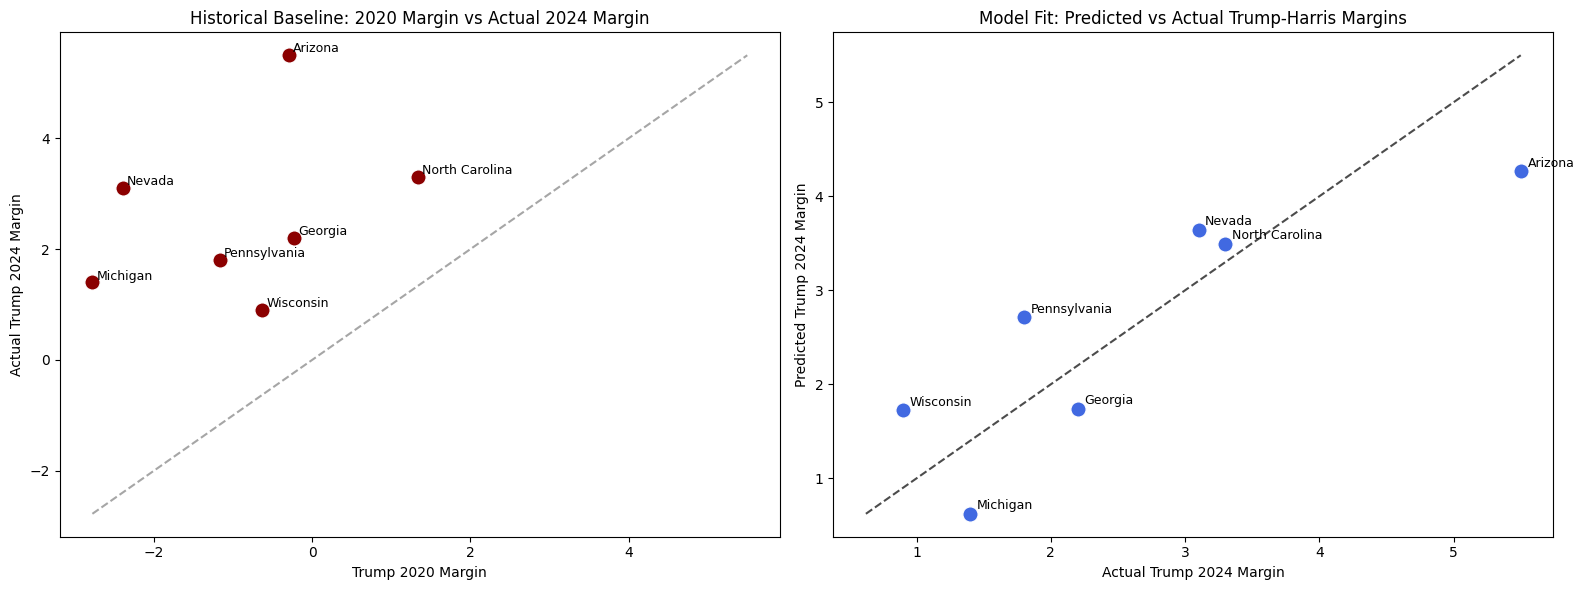


=== DYNAMIC TRAJECTORY MODEL ===
                            OLS Regression Results                            
Dep. Variable:               momentum   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.01894
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               1.00
Time:                        06:53:58   Log-Likelihood:                -24674.
No. Observations:               22632   AIC:                         4.945e+04
Df Residuals:                   22580   BIC:                         4.987e+04
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------

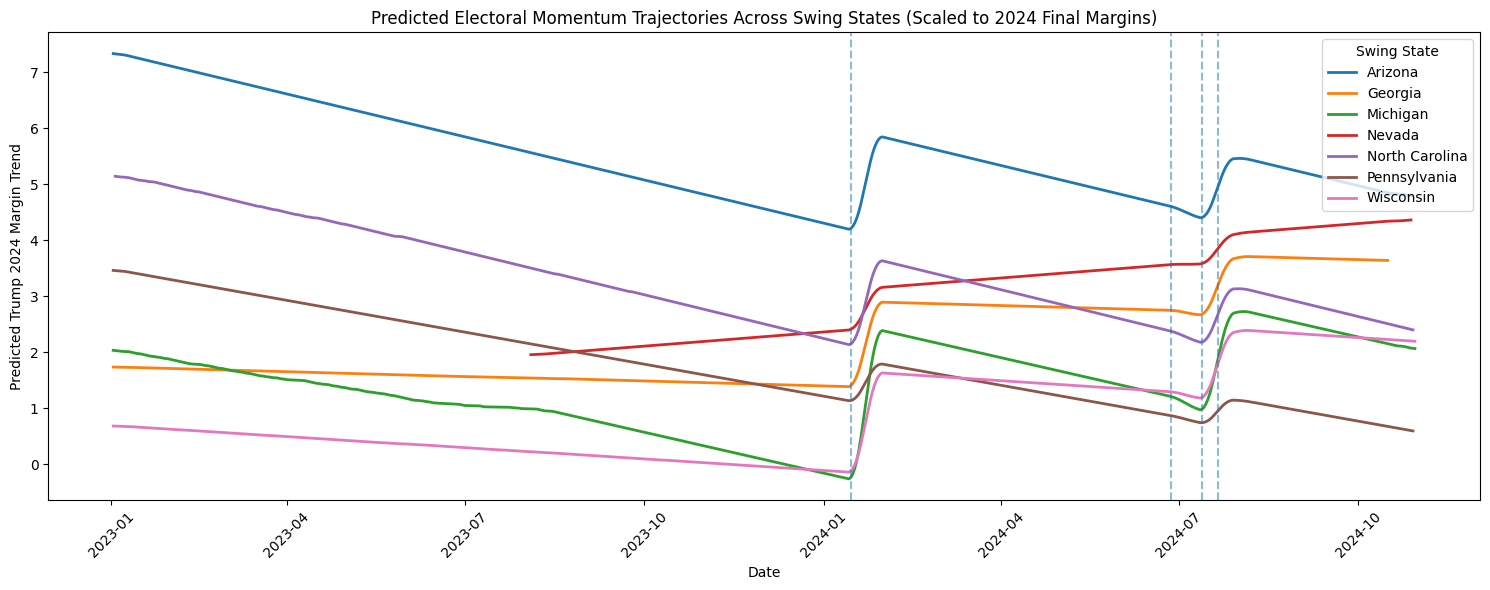

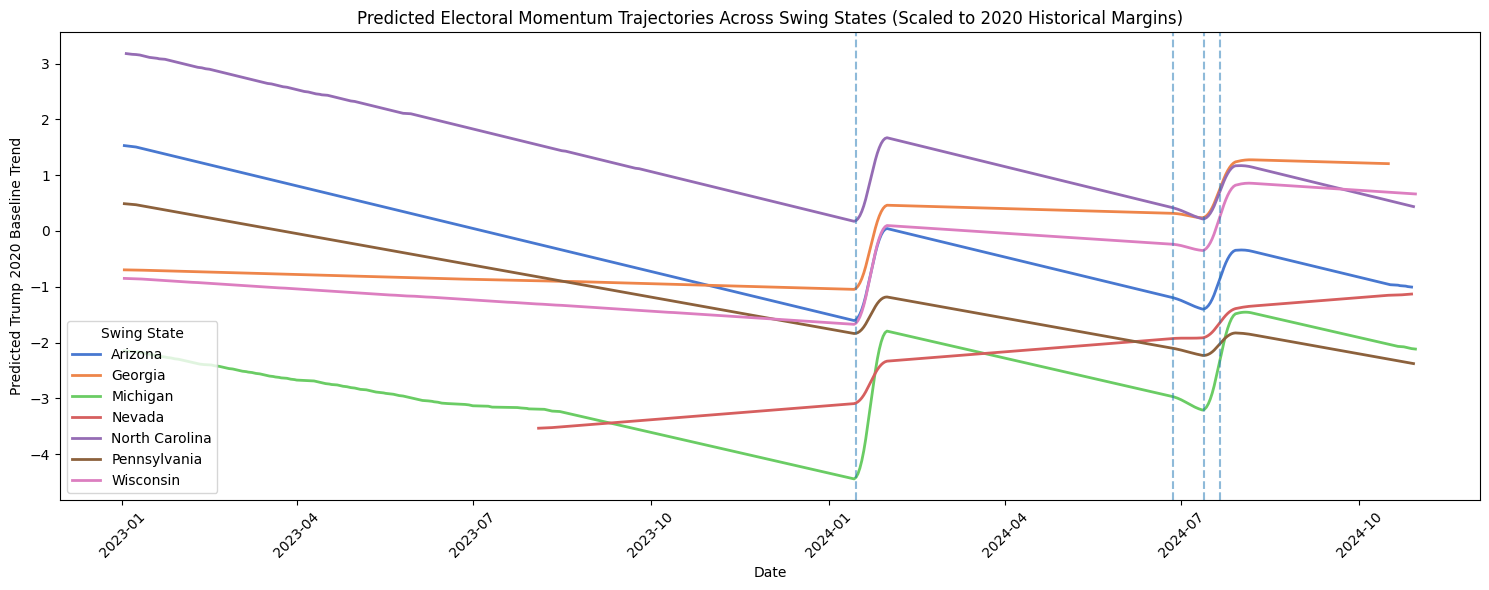

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# ================================
# 10. LOAD FINAL ELECTION RESULTS, now included new past election data
# ================================

results = pd.read_csv(
    MARGINS_CSV
)

# Kept "trump_margin" renaming intact as requested to create final_margin
results.rename(columns={
    "trump_margin": "final_margin"
}, inplace=True)

results["state"] = results["state"].astype(str)

# ================================
# 11. BUILD STATE-LEVEL FEATURES
# ================================

did_cols = [f"{event}_did" for event in events.keys()]

state_features = daily.groupby("state").agg({
    "tweet_volume": "mean",
    "reply_volume": "mean",
    "log_volume": "mean",
    **{col: "sum" for col in did_cols}
}).reset_index()

# Engagement intensity
state_features["engagement_rate"] = (
    state_features["reply_volume"] /
    state_features["tweet_volume"]
)

# ================================
# 12. MERGE FINAL ELECTION OUTCOMES
# ================================

state_features = state_features.merge(
    results,
    on="state",
    how="left"
)

print("\n=== STATE FEATURES ===")
print(state_features)

# ================================
# 13. FINAL ELECTION PREDICTION MODEL
# ================================

# Added trump_margin_2020 here to control for prior election performance
formula = """
final_margin
~ trump_margin_2020
+ engagement_rate
+ log_volume
+ campaign_start_did
+ debate_did
+ trump_incident_did
+ biden_dropout_did
"""

final_model = smf.ols(
    formula=formula,
    data=state_features
).fit()

print("\n=== FINAL ELECTION MODEL ===")
print(final_model.summary())

# ================================
# 14. GENERATE PREDICTIONS
# ================================

state_features["predicted_margin"] = (
    final_model.predict(state_features)
)

# Prediction error
state_features["prediction_error"] = (
    state_features["final_margin"] -
    state_features["predicted_margin"]
)

print("\n=== PREDICTIONS ===")
print(
    state_features[
        [
            "state",
            "final_margin",
            "predicted_margin",
            "prediction_error"
        ]
    ]
)

# ================================
# 15. VISUALIZATION: 
# RESPECTIVE PLOTS FOR 2020 MARGINS & PREDICTIONS
# ================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Baseline Historical Correlation (2020 vs 2024 Actual) ---
sns.scatterplot(
    data=state_features,
    x="trump_margin_2020",
    y="final_margin",
    s=120,
    color="darkred",
    ax=ax1
)

for _, row in state_features.iterrows():
    ax1.text(
        row["trump_margin_2020"] + 0.05,
        row["final_margin"] + 0.05,
        row["state"],
        fontsize=9
    )

# Reference baseline diagonal
min_val_1 = min(state_features["trump_margin_2020"].min(), state_features["final_margin"].min())
max_val_1 = max(state_features["trump_margin_2020"].max(), state_features["final_margin"].max())
ax1.plot([min_val_1, max_val_1], [min_val_1, max_val_1], linestyle="--", color="gray", alpha=0.7)

ax1.set_xlabel("Trump 2020 Margin")
ax1.set_ylabel("Actual Trump 2024 Margin")
ax1.set_title("Historical Baseline: 2020 Margin vs Actual 2024 Margin")

# --- Plot 2: Model Performance (Predicted vs Actual 2024) ---
sns.scatterplot(
    data=state_features,
    x="final_margin",
    y="predicted_margin",
    s=120,
    color="royalblue",
    ax=ax2
)

for _, row in state_features.iterrows():
    ax2.text(
        row["final_margin"] + 0.05,
        row["predicted_margin"] + 0.05,
        row["state"],
        fontsize=9
    )

# Perfect prediction reference line
min_val_2 = min(state_features["final_margin"].min(), state_features["predicted_margin"].min())
max_val_2 = max(state_features["final_margin"].max(), state_features["predicted_margin"].max())
ax2.plot([min_val_2, max_val_2], [min_val_2, max_val_2], linestyle="--", color="black", alpha=0.7)

ax2.set_xlabel("Actual Trump 2024 Margin")
ax2.set_ylabel("Predicted Trump 2024 Margin")
ax2.set_title("Model Fit: Predicted vs Actual Trump-Harris Margins")

plt.tight_layout()
plt.show()

# ================================
# 16. DYNAMIC TRAJECTORY MODEL
# ================================

daily = daily.sort_values(["state", "date"]).copy()

# Daily momentum proxy (within panel order; first day per state is NA)
daily["momentum"] = daily.groupby("state")["log_volume"].diff()

traj_data = daily.dropna(subset=["momentum"]).copy()

trajectory_formula = """
momentum
~ campaign_start_did
+ debate_did
+ trump_incident_did
+ biden_dropout_did
+ C(state_id)
"""

trajectory_model = smf.ols(
    formula=trajectory_formula,
    data=traj_data,
).fit()

print("\n=== DYNAMIC TRAJECTORY MODEL ===")
print(trajectory_model.summary())

daily["predicted_momentum"] = np.nan
daily.loc[traj_data.index, "predicted_momentum"] = trajectory_model.predict(traj_data)

# ================================
# CONVERT MOMENTUM INTO TRAJECTORY
# ================================

daily["trajectory"] = (
    daily.groupby("state")["predicted_momentum"]
    .cumsum()
)

daily["trajectory_smooth"] = (
    daily.groupby("state")["trajectory"]
    .transform(lambda x: x.rolling(7, min_periods=1).mean())
)

# ================================
# NORMALIZE & SCALE TO BOTH BASELINES
# ================================

final_margin_map_2024 = dict(zip(results["state"], results["final_margin"]))
prior_margin_map_2020 = dict(zip(results["state"], results["trump_margin_2020"]))

daily["trajectory_scaled_2024"] = np.nan
daily["trajectory_scaled_2020"] = np.nan

for state in daily["state"].unique():
    mask = daily["state"] == state
    traj = daily.loc[mask, "trajectory_smooth"]
    
    if traj.std() == 0 or traj.isna().all():
        continue
        
    # Standardize underlying momentum
    normalized = (traj - traj.mean()) / traj.std()
    
    # Scale Option 1: Normalized around 2024 Final Margins
    final_margin_2024 = final_margin_map_2024.get(state, 0)
    daily.loc[mask, "trajectory_scaled_2024"] = normalized * 0.8 + final_margin_2024
    
    # Scale Option 2: Normalized around 2020 Historical Margins
    prior_margin_2020 = prior_margin_map_2020.get(state, 0)
    daily.loc[mask, "trajectory_scaled_2020"] = normalized * 0.8 + prior_margin_2020

# ================================
# VISUALIZATION 1: 2024 MARGIN TRAJECTORIES
# ================================

plt.figure(figsize=(15, 6))
sns.lineplot(
    data=daily[daily["treated"] == 1],
    x="date",
    y="trajectory_scaled_2024",
    hue="state",
    linewidth=2,
)

for event_name, event_date in events.items():
    plt.axvline(
        pd.to_datetime(event_date, utc=True),
        linestyle="--",
        alpha=0.5,
    )

plt.title("Predicted Electoral Momentum Trajectories Across Swing States (Scaled to 2024 Final Margins)")
plt.xlabel("Date")
plt.ylabel("Predicted Trump 2024 Margin Trend")
plt.xticks(rotation=45)
plt.legend(title="Swing State")
plt.tight_layout()
plt.show()

# ================================
# VISUALIZATION 2: 2020 MARGIN TRAJECTORIES
# ================================

plt.figure(figsize=(15, 6))
sns.lineplot(
    data=daily[daily["treated"] == 1],
    x="date",
    y="trajectory_scaled_2020",
    hue="state",
    linewidth=2,
    palette="muted" # Slight color variation to separate the plots visually
)

for event_name, event_date in events.items():
    plt.axvline(
        pd.to_datetime(event_date, utc=True),
        linestyle="--",
        alpha=0.5,
    )

plt.title("Predicted Electoral Momentum Trajectories Across Swing States (Scaled to 2020 Historical Margins)")
plt.xlabel("Date")
plt.ylabel("Predicted Trump 2020 Baseline Trend")
plt.xticks(rotation=45)
plt.legend(title="Swing State")
plt.tight_layout()
plt.show()

## Bias audit — engagement concentration (panel)


=== ENGAGEMENT CONCENTRATION ===
                   state  total_volume  avg_volume  engagement_share
3             California        285876  427.318386          0.182888
8                Florida        248889  373.146927          0.159225
31              New York        116417  174.016442          0.074477
41                 Texas        113635  170.623123          0.072697
29            New Jersey         75664  113.269461          0.048406
33                  Ohio         53905  134.092040          0.034485
45            Washington         50321   75.330838          0.032193
4               Colorado         49471   75.183891          0.031649
36          Pennsylvania         47840   71.616766          0.030605
9                Georgia         37679   58.965571          0.024105
27                Nevada         35652   79.403118          0.022808
44              Virginia         32341   48.706325          0.020690
40             Tennessee         32253   48.355322          0.020634


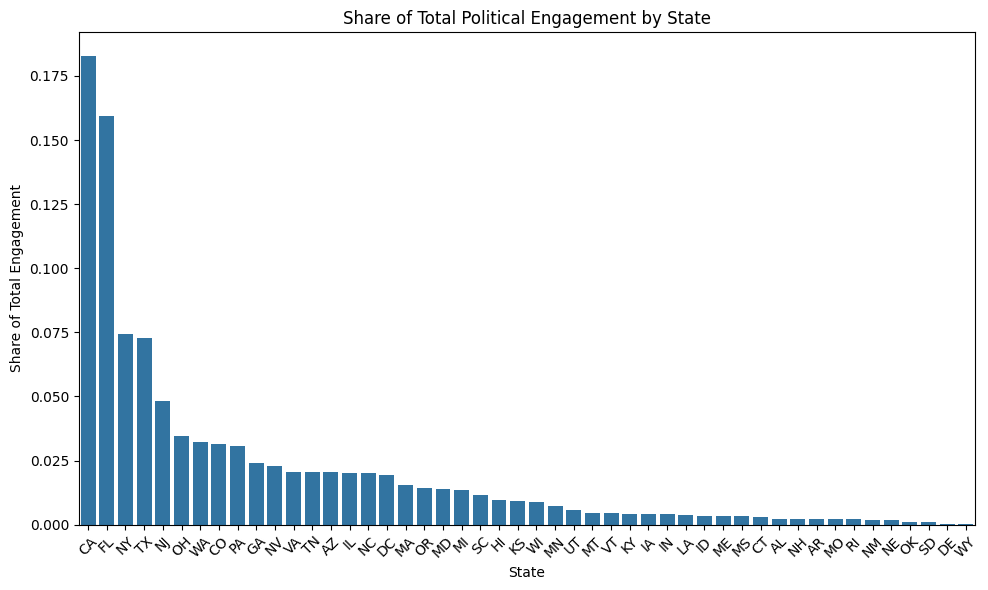

In [14]:
# ================================
# ENGAGEMENT CONCENTRATION TEST
# ================================

state_engagement = (
    daily.groupby("state")
    .agg(
        total_volume=("tweet_volume", "sum"),
        avg_volume=("tweet_volume", "mean")
    )
    .reset_index()
)

# Share of all engagement
total_all = state_engagement["total_volume"].sum()

state_engagement["engagement_share"] = (
    state_engagement["total_volume"] / total_all
)

print("\n=== ENGAGEMENT CONCENTRATION ===")
print(state_engagement.sort_values(
    "engagement_share",
    ascending=False
))

# ----------------------------
# State abbreviation mapping
# ----------------------------
state_abbrev = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC",
    "Unknown": "NA"
}

# Apply abbreviation mapping
state_engagement["state_abbrev"] = state_engagement["state"].map(state_abbrev)

# Optional fallback (in case any state is missing)
state_engagement["state_abbrev"] = state_engagement["state_abbrev"].fillna(state_engagement["state"])

# ----------------------------
# Visualization
# ----------------------------

plt.figure(figsize=(10, 6))

sns.barplot(
    data=state_engagement.sort_values(
        "engagement_share",
        ascending=False
    ),
    x="state_abbrev",
    y="engagement_share"
)

plt.title("Share of Total Political Engagement by State")
plt.ylabel("Share of Total Engagement")
plt.xlabel("State")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Bias audit — representation


20. REPRESENTATION AUDIT (engagement vs 2024 margin)
Correlation(mean log volume, |2024 margin|) = 0.451
Positive => louder states were the LESS competitive ones (visibility != representativeness).
                mean_daily_volume  mean_log_volume  abs_margin
state                                                         
Arizona                    48.496            3.353         5.5
Georgia                    58.966            3.118         2.2
Michigan                   36.589            2.939         1.4
Nevada                     79.403            3.566         3.1
North Carolina             48.309            3.144         3.2
Pennsylvania               71.617            3.744         1.7
Wisconsin                  21.234            2.305         0.9


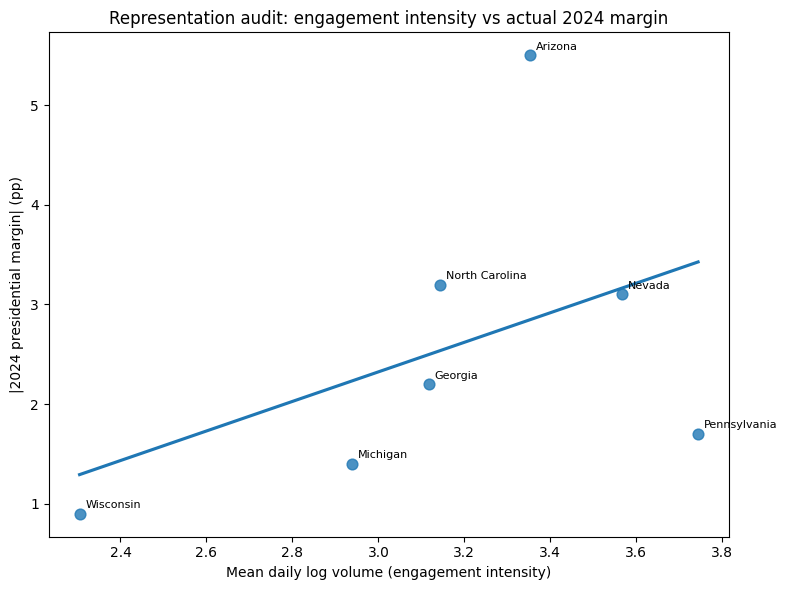


BIAS AUDIT COMPLETE

=== REPRESENTATION BIAS TEST ===
                   state  engagement_rate  predicted_margin  final_margin  \
0                Alabama         0.125536          5.885825           NaN   
1                Arizona         0.894404          4.067770           5.5   
2               Arkansas         0.960354         11.841360           NaN   
3             California         0.677594         16.394963           NaN   
4               Colorado         0.786097         13.482274           NaN   
5            Connecticut         0.999774         11.284577           NaN   
6               Delaware         1.000000          9.913224           NaN   
7   District of Columbia         0.682665         12.195773           NaN   
8                Florida         0.835051         19.166758           NaN   
9                Georgia         0.606969          1.440295           2.2   
10                Hawaii         0.602982         10.778308           NaN   
11                 Id

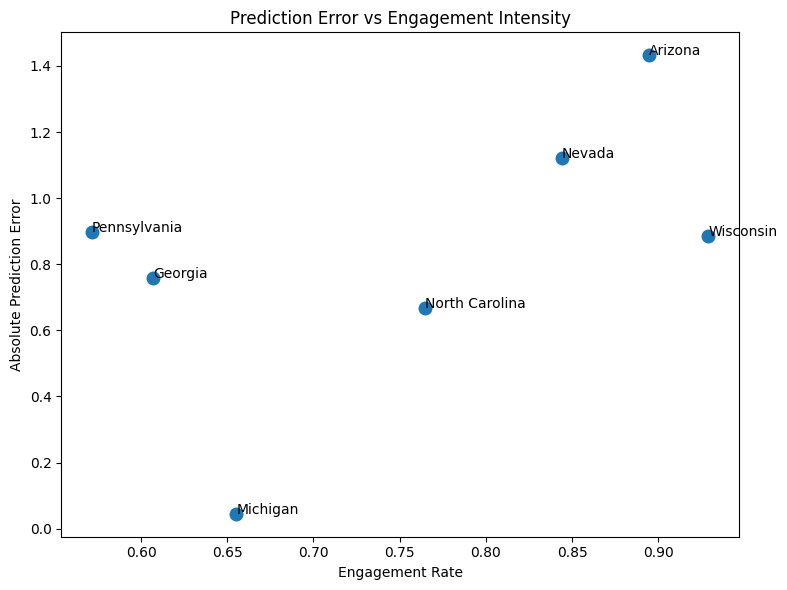

In [15]:
# ================================
# 20. REPRESENTATION AUDIT  [B: engagement vs actual election margins]
# ================================
# Compare online engagement intensity against external ground truth: the
# certified 2024 presidential margin (abs. pp) in each swing state. Tests
# whether higher visibility tracks real electoral competitiveness.
# Source: certified 2024 results (Trump - Harris margin, percentage points).
actual_margin_2024 = {
    "Arizona": 5.5,
    "Georgia": 2.2,
    "Michigan": 1.4,
    "Nevada": 3.1,
    "North Carolina": 3.2,
    "Pennsylvania": 1.7,
    "Wisconsin": 0.9,
}

swing_intensity = (
    daily[daily["state"].isin(swing_states)]
    .groupby("state")
    .agg(mean_daily_volume=("tweet_volume", "mean"),
         mean_log_volume=("log_volume", "mean"))
)
swing_intensity["abs_margin"] = swing_intensity.index.map(actual_margin_2024)
swing_intensity = swing_intensity.dropna(subset=["abs_margin"])

print(f"\n{'=' * 60}\n20. REPRESENTATION AUDIT (engagement vs 2024 margin)\n{'=' * 60}")
if len(swing_intensity) >= 3:
    corr = swing_intensity["mean_log_volume"].corr(swing_intensity["abs_margin"])
    print(f"Correlation(mean log volume, |2024 margin|) = {corr:.3f}")
    print("Positive => louder states were the LESS competitive ones "
          "(visibility != representativeness).")
    print(swing_intensity.round(3).to_string())

    plt.figure(figsize=(8, 6))
    sns.regplot(data=swing_intensity, x="mean_log_volume", y="abs_margin",
                ci=None, scatter_kws={"s": 60})
    for state, row in swing_intensity.iterrows():
        plt.annotate(state, (row["mean_log_volume"], row["abs_margin"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")
    plt.title("Representation audit: engagement intensity vs actual 2024 margin")
    plt.xlabel("Mean daily log volume (engagement intensity)")
    plt.ylabel("|2024 presidential margin| (pp)")
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient swing-state coverage for representation audit.")

print(f"\n{'=' * 60}\nBIAS AUDIT COMPLETE\n{'=' * 60}")

state_features["absolute_error"] = (
    state_features["prediction_error"].abs()
)

print("\n=== REPRESENTATION BIAS TEST ===")

print(
    state_features[
        [
            "state",
            "engagement_rate",
            "predicted_margin",
            "final_margin",
            "absolute_error"
        ]
    ]
)

# Scatterplot

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=state_features,
    x="engagement_rate",
    y="absolute_error",
    s=120
)

for _, row in state_features.iterrows():
    plt.text(
        row["engagement_rate"],
        row["absolute_error"],
        row["state"]
    )

plt.title(
    "Prediction Error vs Engagement Intensity"
)

plt.xlabel("Engagement Rate")
plt.ylabel("Absolute Prediction Error")

plt.tight_layout()
plt.show()

## Bias audit — viral spike inequality


=== VIRAL DAYS ===
                         date  tweet_volume
603 2024-08-26 00:00:00+00:00         10474
606 2024-08-29 00:00:00+00:00         10667
607 2024-08-30 00:00:00+00:00         10296
612 2024-09-04 00:00:00+00:00         10716
613 2024-09-05 00:00:00+00:00         11253
614 2024-09-06 00:00:00+00:00         11642
616 2024-09-08 00:00:00+00:00         10641
617 2024-09-09 00:00:00+00:00         12886
618 2024-09-10 00:00:00+00:00         12684
619 2024-09-11 00:00:00+00:00         18215
620 2024-09-12 00:00:00+00:00         14222
621 2024-09-13 00:00:00+00:00         13441
622 2024-09-14 00:00:00+00:00         12702
623 2024-09-15 00:00:00+00:00         13398
624 2024-09-16 00:00:00+00:00         14359
625 2024-09-17 00:00:00+00:00         17214
626 2024-09-18 00:00:00+00:00         15738
627 2024-09-19 00:00:00+00:00         16059
628 2024-09-20 00:00:00+00:00         12066
630 2024-09-22 00:00:00+00:00         11897
631 2024-09-23 00:00:00+00:00         11534
632 2024-09-

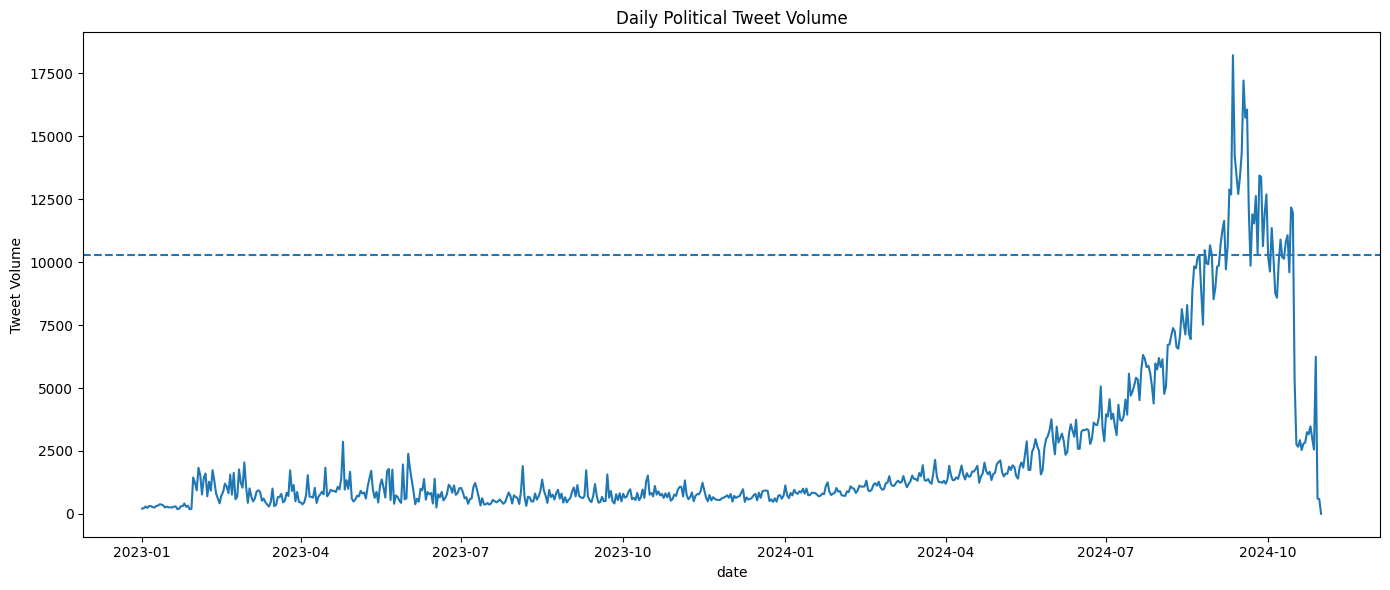

In [16]:
# ================================
# VIRAL SPIKE INEQUALITY TEST
# ================================

daily_total = (
    daily.groupby("date")["tweet_volume"]
    .sum()
    .reset_index()
)

threshold = daily_total["tweet_volume"].quantile(0.95)

viral_days = daily_total[
    daily_total["tweet_volume"] >= threshold
]

print("\n=== VIRAL DAYS ===")
print(viral_days)

# Visualization

plt.figure(figsize=(14,6))

sns.lineplot(
    data=daily_total,
    x="date",
    y="tweet_volume"
)

plt.axhline(
    threshold,
    linestyle="--"
)

plt.title("Daily Political Tweet Volume")
plt.ylabel("Tweet Volume")

plt.tight_layout()
plt.show()

## Bias audit — missingness by state

In [17]:
# ================================
# MISSINGNESS AUDIT
# ================================

missing_by_state = (
    daily.groupby("state")
    .apply(lambda x: x.isna().mean())
)

print("\n=== MISSINGNESS BY STATE ===")
print(missing_by_state)

# Missing dates

date_counts = (
    daily.groupby("state")["date"]
    .nunique()
    .reset_index(name="observed_days")
)

print("\n=== OBSERVED DAYS ===")
print(date_counts)


=== MISSINGNESS BY STATE ===
                      state  date  tweet_volume  reply_volume  treated  \
state                                                                    
Alabama                 0.0   0.0           0.0           0.0      0.0   
Arizona                 0.0   0.0           0.0           0.0      0.0   
Arkansas                0.0   0.0           0.0           0.0      0.0   
California              0.0   0.0           0.0           0.0      0.0   
Colorado                0.0   0.0           0.0           0.0      0.0   
Connecticut             0.0   0.0           0.0           0.0      0.0   
Delaware                0.0   0.0           0.0           0.0      0.0   
District of Columbia    0.0   0.0           0.0           0.0      0.0   
Florida                 0.0   0.0           0.0           0.0      0.0   
Georgia                 0.0   0.0           0.0           0.0      0.0   
Hawaii                  0.0   0.0           0.0           0.0      0.0   
Idaho   

C:\Users\19241\AppData\Local\Temp\ipykernel_15992\3845960362.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.isna().mean())


## Bias audit — amplification & DiD spike sensitivity


=== AMPLIFICATION AUDIT ===


C:\Users\19241\AppData\Roaming\Python\Python312\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 718, but rank is 717
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:     predicted_momentum   R-squared:                       0.761
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                 1.940e+05
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        06:28:17   Log-Likelihood:             1.0536e+05
No. Observations:               22632   AIC:                        -2.093e+05
Df Residuals:                   21914   BIC:                        -2.035e+05
Df Model:                         717                                         
Covariance Type:                  HC1                                         
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

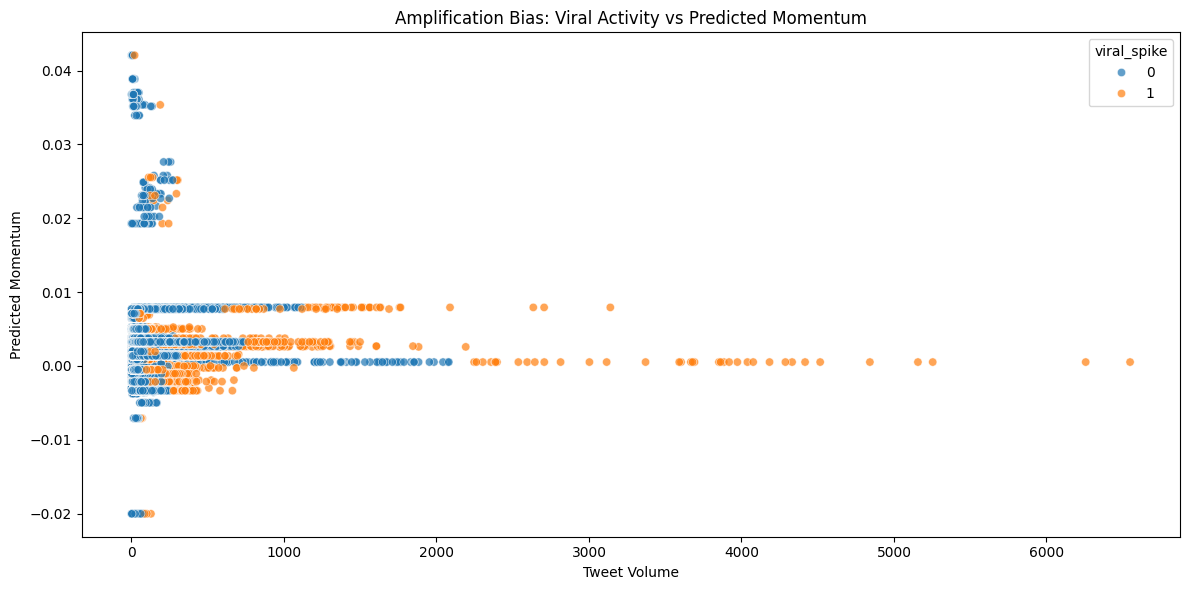


=== VIRAL VS NON-VIRAL PERIODS ===
             tweet_volume  reply_volume  predicted_momentum  \
viral_spike                                                   
0               46.895120     31.873285            0.001830   
1              447.812199    332.024077            0.001828   

             amplification_rate  
viral_spike                      
0                      0.621226  
1                      0.723077  

Spike-sensitivity DiD (fast FE transform; coef_full from 'effects' when present)...
  campaign_start...
  debate...
  trump_incident...
  biden_dropout...

18. AMPLIFICATION AUDIT (spike sensitivity)
Spike days flagged (top 5% within state): 1,130
DiD coefficient with vs without viral spike days:
         event  coef_full  coef_no_spike  abs_change
campaign_start     0.1035         0.0520      0.0514
        debate     0.1042         0.2522      0.1480
trump_incident     0.4415         0.6595      0.2180
 biden_dropout     0.2117         0.4793      0.2677


In [18]:
# ------------------------------------------
# 0. PREREQUISITE: predicted_momentum (from Poll prediction & trajectory)
# ------------------------------------------
if "predicted_momentum" not in daily.columns:
    raise NameError(
        "Column 'predicted_momentum' is missing. Run the cell "
        "'## Poll prediction & trajectory' first (section 15 builds it)."
    )

# ------------------------------------------
# 1. AMPLIFICATION METRICS
# ------------------------------------------

# Reply intensity
daily["amplification_rate"] = (
    daily["reply_volume"] /
    daily["tweet_volume"]
)

# Replace divide-by-zero or inf values
daily["amplification_rate"] = (
    daily["amplification_rate"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

# ------------------------------------------
# 2. VIRAL SPIKE DETECTION
# ------------------------------------------

# State-level z-score of tweet activity
def _volume_zscore(x):
    sd = x.std()
    if sd == 0 or np.isnan(sd):
        return x * 0.0
    return (x - x.mean()) / sd


daily["volume_zscore"] = (
    daily.groupby("state")["tweet_volume"].transform(_volume_zscore)
)

# Viral periods = unusually high activity
daily["viral_spike"] = (
    daily["volume_zscore"] > 2
).astype(int)

# ------------------------------------------
# 3. AMPLIFICATION MODEL
# ------------------------------------------

# Test whether amplification predicts momentum
amplification_formula = """
predicted_momentum
~ amplification_rate
+ viral_spike
+ C(state_id)
+ C(date_id)
"""

# HC1 is much faster than HC3 on large state×date FE panels (same point estimates).
amplification_model = smf.ols(
    formula=amplification_formula,
    data=daily,
).fit(cov_type="HC1")

print("\n=== AMPLIFICATION AUDIT ===")
print(amplification_model.summary())

# ------------------------------------------
# 4. CONCENTRATION ANALYSIS
# ------------------------------------------

state_engagement = (
    daily.groupby("state")
    .agg(total_volume=("tweet_volume", "sum"))
    .reset_index()
)

# Share of national engagement
total_all = state_engagement["total_volume"].sum()

state_engagement["engagement_share"] = (
    state_engagement["total_volume"] / total_all
)

# Herfindahl-Hirschman Index (HHI)
hhi = (
    state_engagement["engagement_share"] ** 2
).sum()

print("\n=== ENGAGEMENT CONCENTRATION ===")
print(state_engagement.sort_values(
    "engagement_share",
    ascending=False
).head(10))

print(f"\nHHI Concentration Index: {hhi:.4f}")

# ------------------------------------------
# 5. VISUALIZATION: VIRAL SPIKES
# ------------------------------------------

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=daily,
    x="tweet_volume",
    y="predicted_momentum",
    hue="viral_spike",
    alpha=0.7
)

plt.title(
    "Amplification Bias: Viral Activity vs Predicted Momentum"
)

plt.xlabel("Tweet Volume")
plt.ylabel("Predicted Momentum")

plt.tight_layout()
plt.show()

# ------------------------------------------
# 6. EVENT-LEVEL AMPLIFICATION
# ------------------------------------------

event_summary = daily.groupby("viral_spike").agg({
    "tweet_volume": "mean",
    "reply_volume": "mean",
    "predicted_momentum": "mean",
    "amplification_rate": "mean"
})

print("\n=== VIRAL VS NON-VIRAL PERIODS ===")
print(event_summary)

# ================================
# 18. AMPLIFICATION AUDIT  [C: viral-spike sensitivity, mitigation 2]
# ================================
# Flag within-state viral spike days and re-estimate each event DiD with
# spikes removed. If coefficients move sharply, the effect is driven by
# amplified viral activity rather than a stable shift.
SPIKE_QUANTILE = 0.95
daily["state_spike_cut"] = daily.groupby("state")["tweet_volume"].transform(
    lambda x: x.quantile(SPIKE_QUANTILE)
)
daily["is_spike_day"] = (daily["tweet_volume"] > daily["state_spike_cut"]).astype(int)
n_spike = int(daily["is_spike_day"].sum())

daily_no_spike = daily[daily["is_spike_day"] == 0].copy()


def _demean_twfe(data, col):
    """Two-way fixed-effects within transform (state + calendar day)."""
    s = data[col].astype(float)
    return (
        s
        - s.groupby(data["state_id"]).transform("mean")
        - s.groupby(data["date_id"]).transform("mean")
        + s.mean()
    )


def run_event_did_coef_fast(data, event_name):
    """
    DiD coefficient with state and date FE via within transformation.
    Same beta as OLS with C(state_id)+C(date_id); avoids 8× slow HC3 refits here.
    """
    did_col = f"{event_name}_did"
    post_col = f"{event_name}_post"
    if post_col not in data.columns or data[post_col].sum() == 0:
        return np.nan
    y = _demean_twfe(data, "log_volume")
    x = _demean_twfe(data, did_col)
    ok = y.notna() & x.notna()
    yv, xv = y[ok].to_numpy(), x[ok].to_numpy()
    denom = float(np.dot(xv, xv))
    if denom == 0:
        return np.nan
    return float(np.dot(xv, yv) / denom)


# Reuse main DiD table from the panel cell when available (full OLS+HC3).
_effects_coef = {}
if "effects" in globals() and hasattr(effects, "iterrows"):
    _effects_coef = dict(zip(effects["event"], effects["coef"]))

print(
    "\nSpike-sensitivity DiD (fast FE transform; "
    "coef_full from 'effects' when present)..."
)
amp_rows = []
for event_name in events:
    print(f"  {event_name}...", flush=True)
    amp_rows.append({
        "event": event_name,
        "coef_full": _effects_coef.get(
            event_name, run_event_did_coef_fast(daily, event_name)
        ),
        "coef_no_spike": run_event_did_coef_fast(daily_no_spike, event_name),
    })

amp = pd.DataFrame(amp_rows)
amp["abs_change"] = (amp["coef_full"] - amp["coef_no_spike"]).abs()
print(f"\n{'=' * 60}\n18. AMPLIFICATION AUDIT (spike sensitivity)\n{'=' * 60}")
print(f"Spike days flagged (top {1 - SPIKE_QUANTILE:.0%} within state): {n_spike:,}")
print("DiD coefficient with vs without viral spike days:")
print(amp.round(4).to_string(index=False))

## Systematic bias audit (Methods_difindif sections 16–20)


16. ENGAGEMENT CONCENTRATION (visibility bias)
States observed:        50
HHI (0-1, higher=worse): 0.0950
Gini (0-1, higher=worse): 0.7011
Top-4 state share:       0.539

Top 10 states by share of engagement volume:
              volume   share  cum_share
state                                  
USA           419259  0.2113     0.2113
California    285876  0.1441     0.3554
Florida       248889  0.1254     0.4808
New York      116417  0.0587     0.5394
Texas         113635  0.0573     0.5967
New Jersey     75664  0.0381     0.6348
Ohio           53905  0.0272     0.6620
Washington     50321  0.0254     0.6874
Colorado       49471  0.0249     0.7123
Pennsylvania   47840  0.0241     0.7364


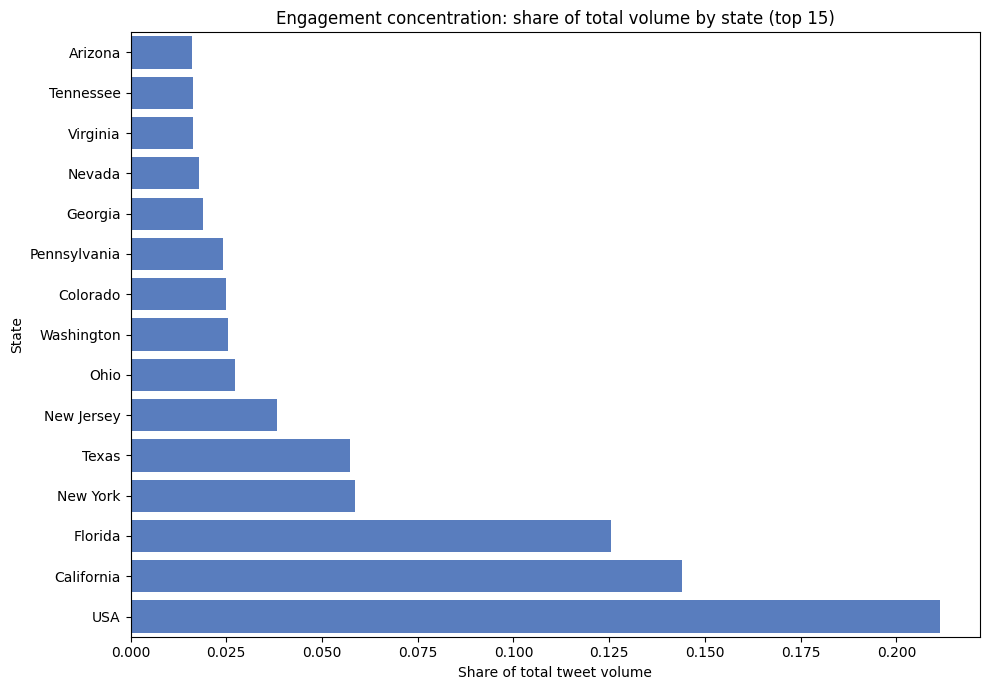


17. MISSINGNESS / COVERAGE REPORT
Rows dropped as ambiguous labels (USA/Unknown/...): 421,210
Calendar span: 670 days
Sparse states (<25% day coverage): 7

Least-covered states:
              state_days  total_volume  median_daily_volume                 first_day                  last_day  coverage_ratio  sparse_flag
state                                                                                                                                       
Wyoming               58           182                  2.0 2023-05-06 00:00:00+00:00 2024-10-28 00:00:00+00:00           0.087         True
Oklahoma              58          1911                  2.0 2023-06-30 00:00:00+00:00 2024-10-31 00:00:00+00:00           0.087         True
Nebraska              83          2778                 30.0 2024-08-09 00:00:00+00:00 2024-10-30 00:00:00+00:00           0.124         True
Rhode Island         111          3155                 19.0 2024-05-30 00:00:00+00:00 2024-09-20 00:00:00+00:00     

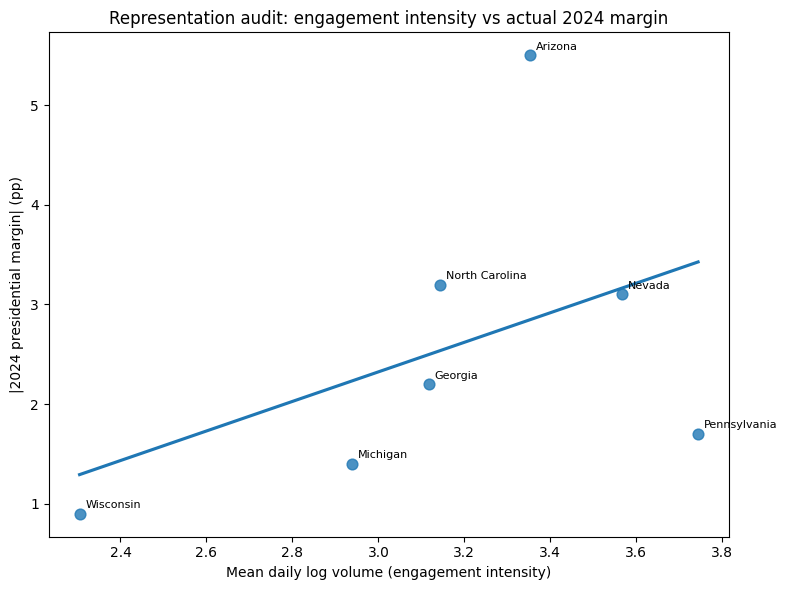


BIAS AUDIT COMPLETE


In [19]:
# ##################################################################
# SYSTEMATIC BIAS AUDIT
# Operationalizes the four testing strategies from the Week 8 audit:
# (A) visibility, (B) participation/representation, (C) amplification,
# (D) salience -- plus the normalization / missingness mitigations.
# ##################################################################

# ================================
# 16. ENGAGEMENT CONCENTRATION ANALYSIS  [A: Visibility bias]
# ================================
# Question: is the signal disproportionately driven by a few high-volume
# states? Computed on the FULL frame (incl. ambiguous labels) so that
# aggregate labels like "USA" are visible in the concentration picture.
state_totals = (
    df_full.groupby("state").size().sort_values(ascending=False)
    .rename("volume").to_frame()
)
total_volume = state_totals["volume"].sum()
state_totals["share"] = state_totals["volume"] / total_volume
state_totals["cum_share"] = state_totals["share"].cumsum()


def herfindahl_index(shares):
    """HHI in [0, 1]; higher = more concentrated."""
    return float(np.sum(np.square(shares)))


def gini(values):
    """Gini coefficient of a non-negative distribution."""
    v = np.sort(np.asarray(values, dtype=float))
    n = v.size
    if n == 0 or v.sum() == 0:
        return np.nan
    cum = np.cumsum(v)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)


hhi = herfindahl_index(state_totals["share"].values)
gini_coef = gini(state_totals["volume"].values)
top4_share = state_totals["share"].head(4).sum()

print(f"\n{'=' * 60}\n16. ENGAGEMENT CONCENTRATION (visibility bias)\n{'=' * 60}")
print(f"States observed:        {len(state_totals)}")
print(f"HHI (0-1, higher=worse): {hhi:.4f}")
print(f"Gini (0-1, higher=worse): {gini_coef:.4f}")
print(f"Top-4 state share:       {top4_share:.3f}")
print("\nTop 10 states by share of engagement volume:")
print(state_totals.head(10).round(4).to_string())

top_n = state_totals.head(15).iloc[::-1]
plt.figure(figsize=(10, 7))
sns.barplot(x=top_n["share"], y=top_n.index, color="#4878CF")
plt.title("Engagement concentration: share of total volume by state (top 15)")
plt.xlabel("Share of total tweet volume")
plt.ylabel("State")
plt.tight_layout()
plt.show()

# ================================
# 17. MISSINGNESS / DATA-COVERAGE REPORT  [mitigation 3]
# ================================
# Sparse states yield unreliable estimates; report coverage transparently.
coverage = (
    daily.groupby("state")
    .agg(
        state_days=("date", "nunique"),
        total_volume=("tweet_volume", "sum"),
        median_daily_volume=("tweet_volume", "median"),
        first_day=("date", "min"),
        last_day=("date", "max"),
    )
    .sort_values("state_days")
)
panel_span_days = (daily["date"].max() - daily["date"].min()).days + 1
coverage["coverage_ratio"] = coverage["state_days"] / panel_span_days
SPARSE_THRESHOLD = 0.25  # <25% of calendar days observed = sparse
coverage["sparse_flag"] = coverage["coverage_ratio"] < SPARSE_THRESHOLD

print(f"\n{'=' * 60}\n17. MISSINGNESS / COVERAGE REPORT\n{'=' * 60}")
print(f"Rows dropped as ambiguous labels (USA/Unknown/...): {n_ambiguous:,}")
print(f"Calendar span: {panel_span_days} days")
print(f"Sparse states (<{SPARSE_THRESHOLD:.0%} day coverage): "
      f"{int(coverage['sparse_flag'].sum())}")
print("\nLeast-covered states:")
print(coverage.head(10).round(3).to_string())

# ================================
# 18. AMPLIFICATION AUDIT  [C: viral-spike sensitivity, mitigation 2]
# ================================
# Flag within-state viral spike days and re-estimate each event DiD with
# spikes removed. If coefficients move sharply, the effect is driven by
# amplified viral activity rather than a stable shift.
SPIKE_QUANTILE = 0.95
daily["state_spike_cut"] = daily.groupby("state")["tweet_volume"].transform(
    lambda x: x.quantile(SPIKE_QUANTILE)
)
daily["is_spike_day"] = (daily["tweet_volume"] > daily["state_spike_cut"]).astype(int)
n_spike = int(daily["is_spike_day"].sum())

daily_no_spike = daily[daily["is_spike_day"] == 0].copy()

_effects_coef = dict(zip(effects["event"], effects["coef"])) if "effects" in globals() else {}

def _demean_twfe(data, col):
    s = data[col].astype(float)
    return (
        s - s.groupby(data["state_id"]).transform("mean")
        - s.groupby(data["date_id"]).transform("mean") + s.mean()
    )

def run_event_did_coef_fast(data, event_name):
    did_col = f"{event_name}_did"
    post_col = f"{event_name}_post"
    if post_col not in data.columns or data[post_col].sum() == 0:
        return np.nan
    y, x = _demean_twfe(data, "log_volume"), _demean_twfe(data, did_col)
    ok = y.notna() & x.notna()
    yv, xv = y[ok].to_numpy(), x[ok].to_numpy()
    denom = float(np.dot(xv, xv))
    return np.nan if denom == 0 else float(np.dot(xv, yv) / denom)

amp_rows = []
for event_name in events:
    amp_rows.append({
        "event": event_name,
        "coef_full": _effects_coef.get(event_name, run_event_did_coef_fast(daily, event_name)),
        "coef_no_spike": run_event_did_coef_fast(daily_no_spike, event_name),
    })

amp = pd.DataFrame(amp_rows)
amp["abs_change"] = (amp["coef_full"] - amp["coef_no_spike"]).abs()
print(f"\n{'=' * 60}\n18. AMPLIFICATION AUDIT (spike sensitivity)\n{'=' * 60}")
print(f"Spike days flagged (top {1 - SPIKE_QUANTILE:.0%} within state): {n_spike:,}")
print("DiD coefficient with vs without viral spike days:")
print(amp.round(4).to_string(index=False))

# ================================
# 19. NORMALIZED-OUTCOME ROBUSTNESS  [mitigation 1]
# ================================
# Re-estimate each event on the within-state standardized outcome so the
# result cannot be driven by large states' raw volume scale.
norm_rows = []
for event_name in events:
    did_col = f"{event_name}_did"
    if daily[f"{event_name}_post"].sum() == 0:
        continue
    formula_norm = f"log_volume_state_z ~ {did_col} + C(state_id) + C(date_id)"
    m = smf.ols(formula_norm, data=daily).fit(cov_type="HC3")
    norm_rows.append({
        "event": event_name,
        "coef_norm": m.params[did_col],
        "p_value_norm": m.pvalues[did_col],
    })
norm = pd.DataFrame(norm_rows)
print(f"\n{'=' * 60}\n19. NORMALIZED-OUTCOME DiD (within-state z-score)\n{'=' * 60}")
print(norm.round(4).to_string(index=False))

# ================================
# 20. REPRESENTATION AUDIT  [B: engagement vs actual election margins]
# ================================
# Compare online engagement intensity against external ground truth: the
# certified 2024 presidential margin (abs. pp) in each swing state. Tests
# whether higher visibility tracks real electoral competitiveness.
# Source: certified 2024 results (Trump - Harris margin, percentage points).
actual_margin_2024 = {
    "Arizona": 5.5,
    "Georgia": 2.2,
    "Michigan": 1.4,
    "Nevada": 3.1,
    "North Carolina": 3.2,
    "Pennsylvania": 1.7,
    "Wisconsin": 0.9,
}

swing_intensity = (
    daily[daily["state"].isin(swing_states)]
    .groupby("state")
    .agg(mean_daily_volume=("tweet_volume", "mean"),
         mean_log_volume=("log_volume", "mean"))
)
swing_intensity["abs_margin"] = swing_intensity.index.map(actual_margin_2024)
swing_intensity = swing_intensity.dropna(subset=["abs_margin"])

print(f"\n{'=' * 60}\n20. REPRESENTATION AUDIT (engagement vs 2024 margin)\n{'=' * 60}")
if len(swing_intensity) >= 3:
    corr = swing_intensity["mean_log_volume"].corr(swing_intensity["abs_margin"])
    print(f"Correlation(mean log volume, |2024 margin|) = {corr:.3f}")
    print("Positive => louder states were the LESS competitive ones "
          "(visibility != representativeness).")
    print(swing_intensity.round(3).to_string())

    plt.figure(figsize=(8, 6))
    sns.regplot(data=swing_intensity, x="mean_log_volume", y="abs_margin",
                ci=None, scatter_kws={"s": 60})
    for state, row in swing_intensity.iterrows():
        plt.annotate(state, (row["mean_log_volume"], row["abs_margin"]),
                     fontsize=8, xytext=(4, 4), textcoords="offset points")
    plt.title("Representation audit: engagement intensity vs actual 2024 margin")
    plt.xlabel("Mean daily log volume (engagement intensity)")
    plt.ylabel("|2024 presidential margin| (pp)")
    plt.tight_layout()
    plt.show()
else:
    print("Insufficient swing-state coverage for representation audit.")

print(f"\n{'=' * 60}\nBIAS AUDIT COMPLETE\n{'=' * 60}")